# Test Hybrid Model on Real Time Series

This notebook trains the existing PyTorch hybrid NN-GARCH model on cleaned WIKI prices returns.
Data batches are sampled via `tf.data.Dataset.from_generator` and then fed into the training functions from `engine.py`.


In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import torch

from data_stocks_WIKI_price import get_cleaned_data
from model import HybridGarch
from engine import train_hybrid_garch, eval_log_mse
from visualization import (
    plot_training_curves,
    collect_true_pred_sigma2,
    plot_true_pred_scatter,
    plot_predictions_analysis,
)


In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
tf.random.set_seed(SEED)

FILE_PATH = r"C:/Users/karim/OneDrive/Documents/Msc AI/Finance/TP/WIKI_PRICES_212b326a081eacca455e13140d7bb9db.zip"

WINDOW_SIZE = 90
BATCH_SIZE = 500

TRAIN_RANGE = (0, 1000)
VAL_RANGE = (1000, 1200)
TEST_RANGE = (1200, 1400)

TRAIN_STEPS = 150
VAL_STEPS = 40
TEST_STEPS = 40

N_EPOCHS = 20
LR = 5e-5 #1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [3]:
returns_df = get_cleaned_data(FILE_PATH)
print("Cleaned returns shape (time, tickers):", returns_df.shape)

if returns_df.shape[0] < TEST_RANGE[1]:
    raise ValueError(f"Not enough rows for requested split end={TEST_RANGE[1]} with T={returns_df.shape[0]}")

returns_values = returns_df.to_numpy(dtype=np.float32)
print("Date range:", returns_df.index.min(), "->", returns_df.index.max())
print("Number of tickers with zero NaN:", returns_df.shape[1])


Cleaned returns shape (time, tickers): (4585, 1390)
Date range: 2000-01-04 00:00:00 -> 2018-03-27 00:00:00
Number of tickers with zero NaN: 1390


In [4]:
def make_range_generator(values, start_idx, end_idx, window_size=90, batch_size=500, seed=None):
    """Infinite generator over one time split; re-samples indices every batch."""
    n_time, n_tickers = values.shape
    if not (0 <= start_idx < end_idx <= n_time):
        raise ValueError(f"Invalid range [{start_idx}, {end_idx}) for n_time={n_time}")

    min_t = start_idx + window_size
    if min_t >= end_idx:
        raise ValueError("Range too short for the given window_size")

    rng = np.random.default_rng(seed)

    def _generator():
        while True:
            ticker_idx = rng.choice(n_tickers, size=batch_size, replace=(n_tickers < batch_size))
            t_idx = rng.integers(low=min_t, high=end_idx, size=batch_size)

            x = np.empty((batch_size, window_size, 1), dtype=np.float32)
            y = np.empty((batch_size,), dtype=np.float32)

            for i, (t, j) in enumerate(zip(t_idx, ticker_idx)):
                x[i, :, 0] = values[t - window_size:t, j]
                # Target proxy for one-step variance on real data
                y[i] = values[t, j] ** 2

            yield x, y

    return _generator


def make_tf_dataset(generator_fn, batch_size=500, window_size=90):
    output_signature = (
        tf.TensorSpec(shape=(batch_size, window_size, 1), dtype=tf.float32),
        tf.TensorSpec(shape=(batch_size,), dtype=tf.float32),
    )
    return tf.data.Dataset.from_generator(generator_fn, output_signature=output_signature).prefetch(tf.data.AUTOTUNE)


class TorchIterableFromTF:
    """Adapter so engine.py can consume tf.data batches without rewriting training logic."""

    def __init__(self, tf_dataset, steps_per_epoch):
        self.tf_dataset = tf_dataset
        self.steps_per_epoch = int(steps_per_epoch)

    def __iter__(self):
        for xb, yb in self.tf_dataset.take(self.steps_per_epoch).as_numpy_iterator():
            yield torch.from_numpy(xb), torch.from_numpy(yb)

    def __len__(self):
        return self.steps_per_epoch


In [8]:
train_gen_fn = make_range_generator(returns_values, *TRAIN_RANGE, window_size=WINDOW_SIZE, batch_size=BATCH_SIZE, seed=SEED)
val_gen_fn = make_range_generator(returns_values, *VAL_RANGE, window_size=WINDOW_SIZE, batch_size=BATCH_SIZE, seed=SEED + 1)
test_gen_fn = make_range_generator(returns_values, *TEST_RANGE, window_size=WINDOW_SIZE, batch_size=BATCH_SIZE, seed=SEED + 2)

train_tf = make_tf_dataset(train_gen_fn, batch_size=BATCH_SIZE, window_size=WINDOW_SIZE)
val_tf = make_tf_dataset(val_gen_fn, batch_size=BATCH_SIZE, window_size=WINDOW_SIZE)
test_tf = make_tf_dataset(test_gen_fn, batch_size=BATCH_SIZE, window_size=WINDOW_SIZE)

train_loader = TorchIterableFromTF(train_tf, TRAIN_STEPS)
val_loader = TorchIterableFromTF(val_tf, VAL_STEPS)
test_loader = TorchIterableFromTF(test_tf, TEST_STEPS)

xb, yb = next(iter(train_loader))
print("Feature batch shape:", tuple(xb.shape))
print("Target batch shape:", tuple(yb.shape))


Feature batch shape: (500, 90, 1)
Target batch shape: (500,)


C:\Users\karim\AppData\Local\Temp\ipykernel_24332\4212260004.py:48: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  yield torch.from_numpy(xb), torch.from_numpy(yb)


In [31]:
model = HybridGarch(hidden=32).to(device)

history = train_hybrid_garch(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=N_EPOCHS,
    lr=LR,
    device=device,
    ckpt_path="hybrid_garch_real.pt",
)


Epoch 01 | train=94.590113 | val=97.036385 | alpha=0.3266 beta=0.2610
Epoch 02 | train=91.654625 | val=93.131451 | alpha=0.3343 beta=0.2565
Epoch 04 | train=85.712650 | val=87.235714 | alpha=0.3384 beta=0.2375
Epoch 06 | train=77.079425 | val=76.211850 | alpha=0.3453 beta=0.1999
Epoch 08 | train=64.154316 | val=61.773032 | alpha=0.3262 beta=0.1476
Epoch 10 | train=47.909911 | val=43.260066 | alpha=0.2544 beta=0.0864
Epoch 12 | train=31.352924 | val=24.841724 | alpha=0.1549 beta=0.0366
Epoch 14 | train=19.122824 | val=11.378457 | alpha=0.0612 beta=0.0098
Epoch 16 | train=14.727488 | val=7.441001 | alpha=0.1022 beta=0.0087
Epoch 18 | train=13.335764 | val=7.902811 | alpha=0.3056 beta=0.0260
Epoch 20 | train=12.949576 | val=8.475119 | alpha=0.4157 beta=0.0691
Best val loss = 7.441001 (log-variance MSE)


Test log-MSE on split (1200, 1400): 7.103725


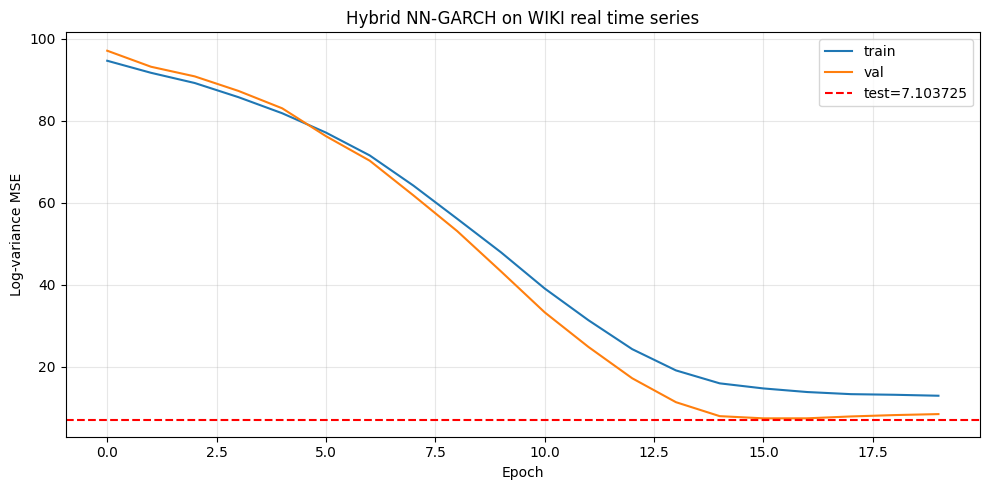

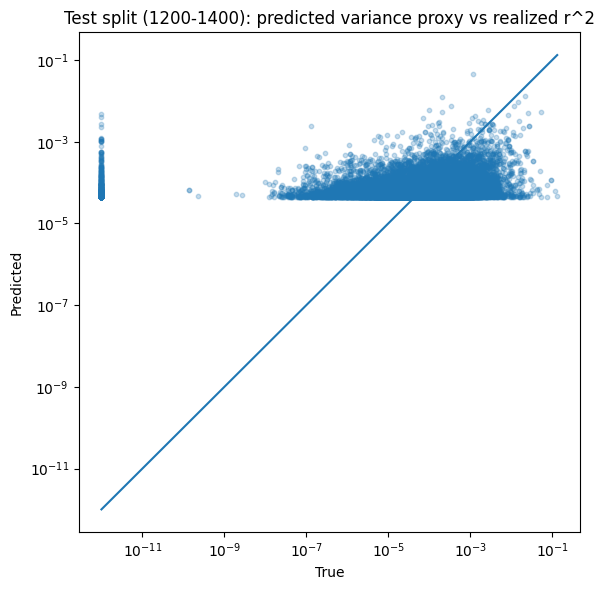

n_points: 20000
mse: 0.000006
log_mse: 14.937412
corr_log: 0.1151


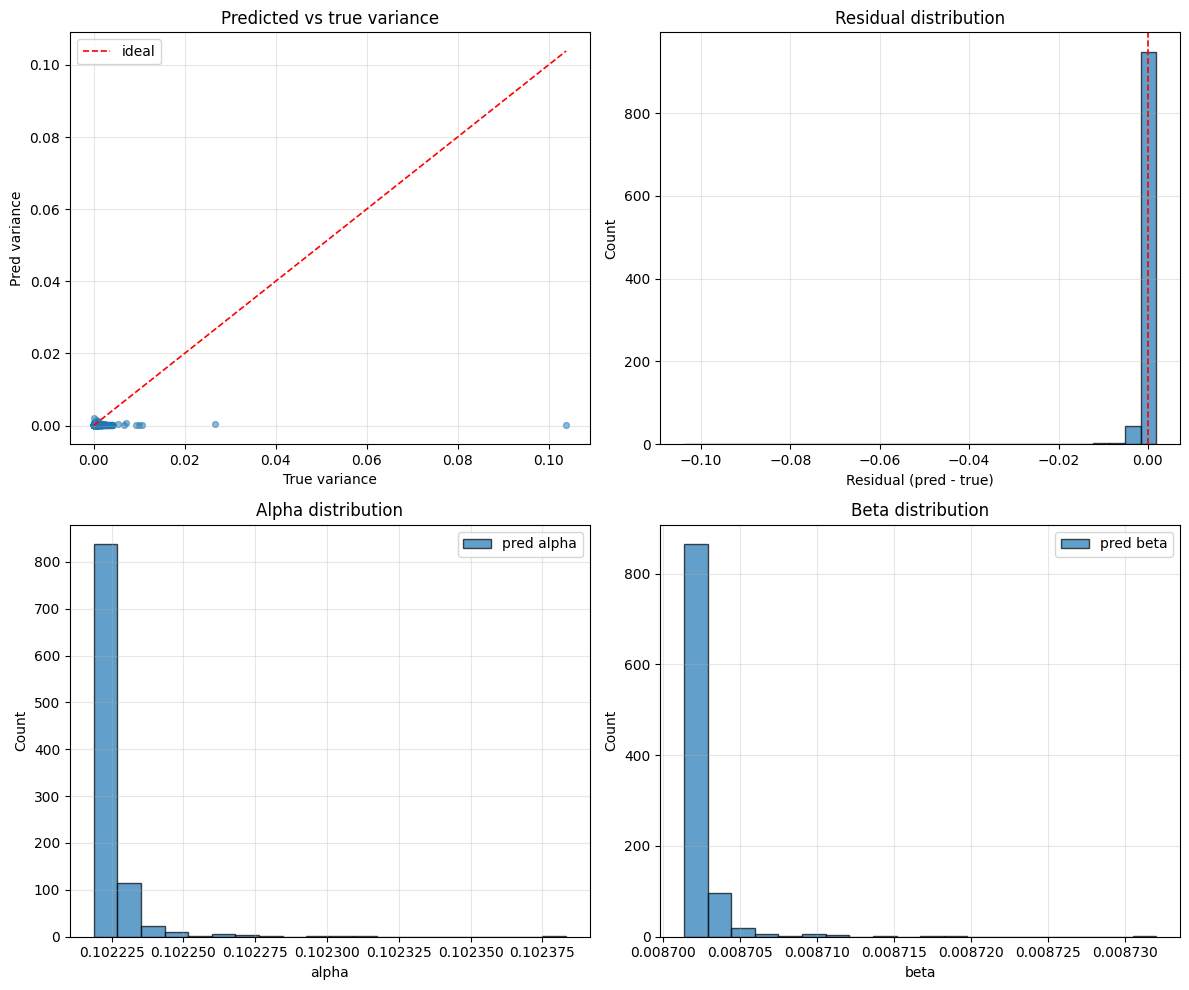

MSE: 0.000012
MAE: 0.000473
R2: 0.0014
alpha mean +/- std: 0.1022 +/- 0.0000
beta mean +/- std: 0.0087 +/- 0.0000
alpha + beta mean: 0.1109


In [32]:
test_log_mse = eval_log_mse(model, test_loader, device)
print(f"Test log-MSE on split {TEST_RANGE}: {test_log_mse:.6f}")

plot_training_curves(history, test_loss=test_log_mse, title="Hybrid NN-GARCH on WIKI real time series")

y_true, y_pred = collect_true_pred_sigma2(model, test_loader, device, max_batches=TEST_STEPS)
_ = plot_true_pred_scatter(
    y_true,
    y_pred,
    to_volatility=False,
    loglog=True,
    title="Test split (1200-1400): predicted variance proxy vs realized r^2",
)

_ = plot_predictions_analysis(model, test_loader, device, n_examples=1000)


In [38]:
import numpy as np
from scipy.stats import pearsonr, spearmanr

eps = 1e-12

# If your scatter is log-log of r^2 vs variance_hat:
x = np.log(np.maximum(y_true, eps))   # true (r^2)
y = np.log(np.maximum(y_pred, eps))   # predicted variance

# Remove non-finite values just in case
m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]

r, p = pearsonr(x, y)
rho, p_s = spearmanr(x, y)

print(f"Pearson r={r:.4f}, p-value={p:.3e}")
print(f"Spearman rho={rho:.4f}, p-value={p_s:.3e}")


Pearson r=0.1061, p-value=3.363e-51
Spearman rho=0.1932, p-value=1.669e-167


In [33]:
import numpy as np
from visualization import collect_true_pred_sigma2
from engine import qlike

y_true, y_pred = collect_true_pred_sigma2(model, test_loader, device, max_batches=TEST_STEPS)
eps = 1e-12
log_true = np.log(np.maximum(y_true, eps))
log_pred = np.log(np.maximum(y_pred, eps))

log_mse = np.mean((log_pred - log_true) ** 2)
corr_log = np.corrcoef(log_true, log_pred)[0, 1]
r2_log = 1 - np.var(log_true - log_pred) / np.var(log_true)
ql = qlike(y_true, y_pred)

print(f"log_mse={log_mse:.6f}, corr_log={corr_log:.4f}, r2_log={r2_log:.4f}, qlike={ql:.6f}")


log_mse=15.116488, corr_log=0.1061, r2_log=0.0090, qlike=-2.646373


In [34]:
import numpy as np
from engine import qlike

eps = 1e-12
mu = np.mean(y_true)                       # constant-variance baseline
y_const = np.full_like(y_true, mu)

# naive baseline: yesterday's realized variance
y_naive = np.r_[y_true[0], y_true[:-1]]

def metrics(y_t, y_p):
    lt = np.log(np.maximum(y_t, eps))
    lp = np.log(np.maximum(y_p, eps))
    return {
        "log_mse": float(np.mean((lp-lt)**2)),
        "corr_log": float(np.corrcoef(lt, lp)[0,1]),
        "r2_log": float(1 - np.var(lt-lp)/np.var(lt)),
        "qlike": float(qlike(y_t, y_p)),
    }

print("model:", metrics(y_true, y_pred))
print("const:", metrics(y_true, y_const))
print("naive:", metrics(y_true, y_naive))


model: {'log_mse': 15.116487503051758, 'corr_log': 0.10613780366730691, 'r2_log': 0.009032905101776123, 'qlike': -2.6463727951049805}
const: {'log_mse': 21.232046127319336, 'corr_log': nan, 'r2_log': 0.0, 'qlike': -6.554873466491699}
naive: {'log_mse': 30.10114288330078, 'corr_log': -0.0013339796837763115, 'r2_log': -1.0026795864105225, 'qlike': 15022686.0}


c:\Users\karim\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\karim\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [35]:
import numpy as np
from engine import rolling_forecast_arch, rolling_forecast_nn, qlike, log_mse_on_r2

# Use same horizon for both: first 1400 points, train=0:1200, test=1200:1400
T_END = 1400
train_ratio = 1200 / 1400
window_size = 90

# optional: sample tickers for speed
n_tickers = returns_df.shape[1]
tickers_idx = np.random.default_rng(42).choice(n_tickers, size=min(200, n_tickers), replace=False)

nn_metrics = []
arch_metrics = []

for j in tickers_idx:
    r = returns_df.iloc[:T_END, j].to_numpy(dtype=np.float64)

    nn_pred, nn_r2, _ = rolling_forecast_nn(
        model=model, r=r, window_size=window_size, train_ratio=train_ratio, device=device
    )
    arch_pred, arch_r2, _ = rolling_forecast_arch(
        r=r, window_size=window_size, train_ratio=train_ratio, refit_every=5
    )

    # align lengths just in case
    m = min(len(nn_pred), len(arch_pred))
    nn_pred, nn_r2 = nn_pred[:m], nn_r2[:m]
    arch_pred, arch_r2 = arch_pred[:m], arch_r2[:m]

    nn_metrics.append([
        log_mse_on_r2(nn_r2, nn_pred),
        qlike(nn_r2, nn_pred),
    ])
    arch_metrics.append([
        log_mse_on_r2(arch_r2, arch_pred),
        qlike(arch_r2, arch_pred),
    ])

nn_metrics = np.array(nn_metrics)
arch_metrics = np.array(arch_metrics)

print("NN   mean log_mse, qlike:", nn_metrics.mean(axis=0))
print("ARCH mean log_mse, qlike:", arch_metrics.mean(axis=0))


NN   mean log_mse, qlike: [ 19.7913708  259.21633377]
ARCH mean log_mse, qlike: [18.88666893 -6.86533279]


## Fine-tunning 

Epoch 01 | train=93.531360 | val=94.594050 | alpha=0.3345 beta=0.2556
Epoch 02 | train=87.408367 | val=86.472691 | alpha=0.3406 beta=0.2359
Epoch 04 | train=67.262477 | val=61.738965 | alpha=0.3408 beta=0.1416
Epoch 06 | train=31.998834 | val=21.852869 | alpha=0.1353 beta=0.0323
Epoch 08 | train=10.818174 | val=7.414934 | alpha=0.0770 beta=0.0112
Epoch 10 | train=10.518762 | val=7.321737 | alpha=0.0574 beta=0.0145
Epoch 12 | train=10.323425 | val=7.281985 | alpha=0.0526 beta=0.0154
Epoch 14 | train=10.171955 | val=7.343253 | alpha=0.0429 beta=0.0130
Epoch 16 | train=10.305970 | val=7.204222 | alpha=0.0407 beta=0.0130
Epoch 18 | train=10.191700 | val=7.124492 | alpha=0.0411 beta=0.0138
Epoch 20 | train=10.248708 | val=7.302338 | alpha=0.0415 beta=0.0153
Best val loss = 6.922608 (log-variance MSE)
Loaded: hybrid_garch_pretrained_synth_full.pt
Missing keys: 0
Unexpected keys: 0
Epoch 01 | train=23.292761 | val=20.033995 | alpha=0.1823 beta=0.8002
Epoch 02 | train=20.688058 | val=17.447206

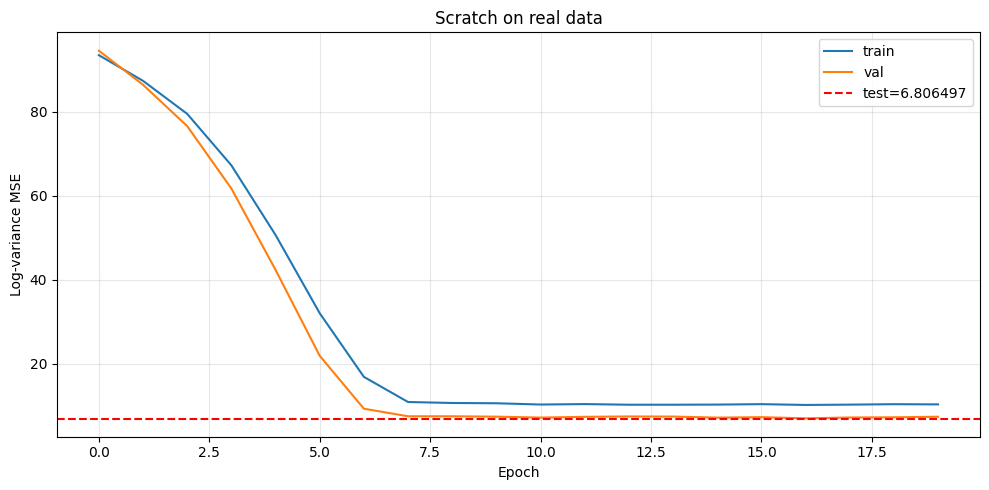

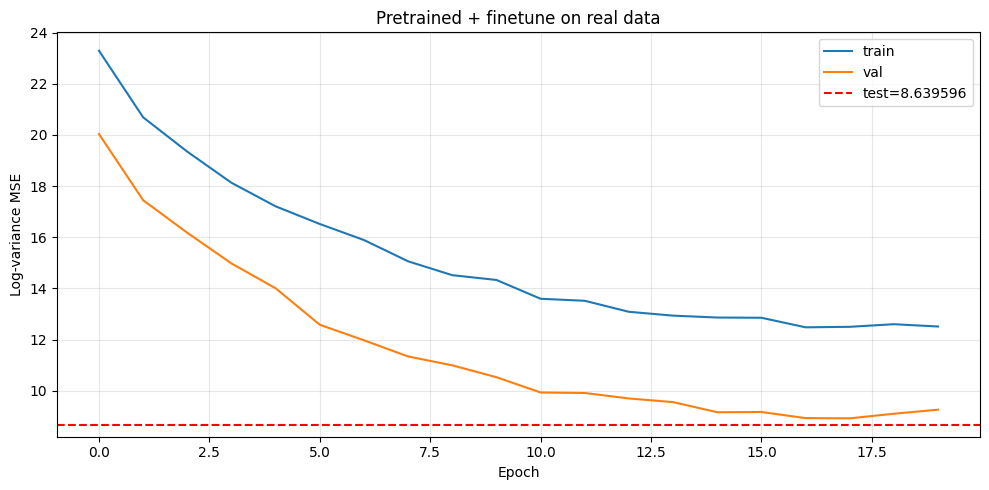

In [10]:
# --- Comparison propre: scratch vs finetune (chargement pretrain correct) ---
import numpy as np
import torch
from model import HybridGarch
from engine import train_hybrid_garch, eval_log_mse
from visualization import plot_training_curves

PRETRAIN_PATH = "hybrid_garch_pretrained_synth_full.pt"

def build_loaders(seed=42):
    train_gen_fn = make_range_generator(
        returns_values, *TRAIN_RANGE, window_size=WINDOW_SIZE, batch_size=BATCH_SIZE, seed=seed
    )
    val_gen_fn = make_range_generator(
        returns_values, *VAL_RANGE, window_size=WINDOW_SIZE, batch_size=BATCH_SIZE, seed=seed + 1
    )
    test_gen_fn = make_range_generator(
        returns_values, *TEST_RANGE, window_size=WINDOW_SIZE, batch_size=BATCH_SIZE, seed=seed + 2
    )

    train_tf = make_tf_dataset(train_gen_fn, batch_size=BATCH_SIZE, window_size=WINDOW_SIZE)
    val_tf = make_tf_dataset(val_gen_fn, batch_size=BATCH_SIZE, window_size=WINDOW_SIZE)
    test_tf = make_tf_dataset(test_gen_fn, batch_size=BATCH_SIZE, window_size=WINDOW_SIZE)

    train_loader = TorchIterableFromTF(train_tf, TRAIN_STEPS)
    val_loader = TorchIterableFromTF(val_tf, VAL_STEPS)
    test_loader = TorchIterableFromTF(test_tf, TEST_STEPS)
    return train_loader, val_loader, test_loader

def load_pretrained(model, path, device):
    ckpt = torch.load(path, map_location=device)
    state = ckpt["model_state"] if isinstance(ckpt, dict) and "model_state" in ckpt else ckpt
    incompat = model.load_state_dict(state, strict=True)
    print("Loaded:", path)
    print("Missing keys:", len(incompat.missing_keys))
    print("Unexpected keys:", len(incompat.unexpected_keys))

def run_experiment(tag, init_ckpt=None, seed=42, lr=1e-4, weight_decay=1e-4):
    np.random.seed(seed)
    torch.manual_seed(seed)

    train_loader, val_loader, test_loader = build_loaders(seed=seed)

    model = HybridGarch(hidden=32).to(device)
    if init_ckpt is not None:
        load_pretrained(model, init_ckpt, device)

    test_before = eval_log_mse(model, test_loader, device)

    history = train_hybrid_garch(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        n_epochs=N_EPOCHS,
        lr=lr,
        device=device,
        ckpt_path=f"{tag}_best.pt",
        weight_decay=weight_decay,
    )

    # Nouveau loader test pour avoir un itérateur frais
    _, _, test_loader_eval = build_loaders(seed=seed)
    test_after = eval_log_mse(model, test_loader_eval, device)

    return {
        "tag": tag,
        "history": history,
        "test_before": test_before,
        "test_after": test_after,
    }

# 1) Scratch
res_scratch = run_experiment(
    tag="scratch_real",
    init_ckpt=None,
    seed=42,
    lr=1e-4,
    weight_decay=1e-4,
)

# 2) Finetune (lr + wd plus faibles)
res_finetune = run_experiment(
    tag="finetune_real",
    init_ckpt=PRETRAIN_PATH,
    seed=42,
    lr=1e-5,
    weight_decay=1e-6,
)

print("\n=== Comparison (test log-MSE) ===")
print(f"Scratch  before: {res_scratch['test_before']:.6f} | after: {res_scratch['test_after']:.6f}")
print(f"Finetune before: {res_finetune['test_before']:.6f} | after: {res_finetune['test_after']:.6f}")

plot_training_curves(res_scratch["history"], test_loss=res_scratch["test_after"], title="Scratch on real data")
plot_training_curves(res_finetune["history"], test_loss=res_finetune["test_after"], title="Pretrained + finetune on real data")


Scratch : {'log_mse': 15.43309896913137, 'corr_log': 0.14898970122933664, 'qlike': -3.2202408926322756}
Finetune: {'log_mse': 17.891087074775662, 'corr_log': 0.1432531523748656, 'qlike': -5.079460108668167}


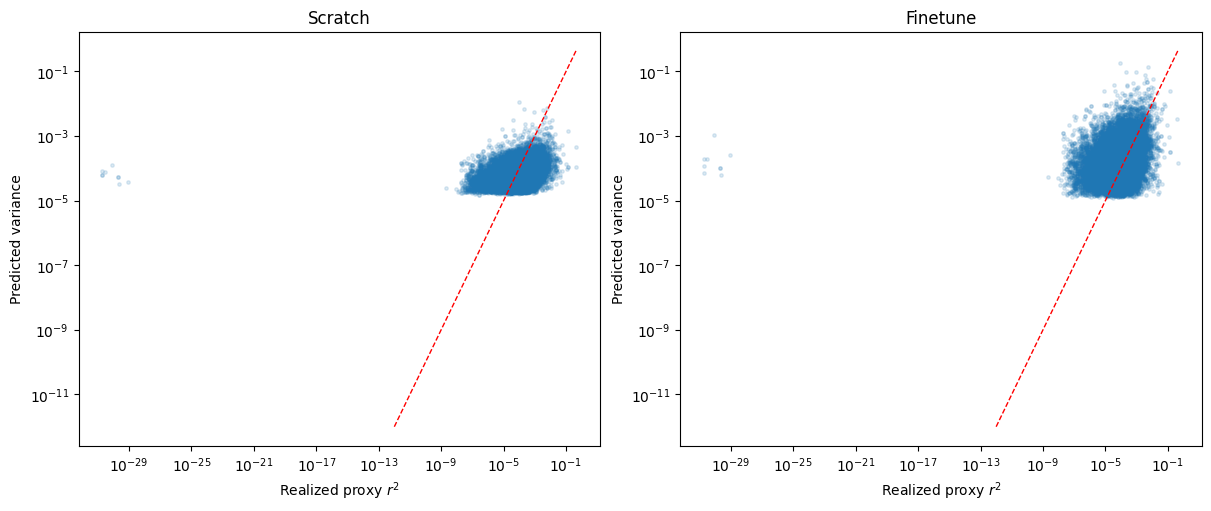

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

from model import HybridGarch

# ---------- fixed test set ----------
def build_fixed_test_loader(values, test_range, window_size, batch_size, steps, seed=44):
    n_time, n_tickers = values.shape
    start_idx, end_idx = test_range
    min_t = start_idx + window_size
    n_samples = batch_size * steps

    rng = np.random.default_rng(seed)
    t_idx = rng.integers(low=min_t, high=end_idx, size=n_samples)
    j_idx = rng.integers(low=0, high=n_tickers, size=n_samples)

    x = np.empty((n_samples, window_size, 1), dtype=np.float32)
    y = np.empty((n_samples,), dtype=np.float32)

    for i, (t, j) in enumerate(zip(t_idx, j_idx)):
        x[i, :, 0] = values[t - window_size:t, j]
        y[i] = values[t, j] ** 2  # realized proxy r^2

    ds = TensorDataset(torch.from_numpy(x), torch.from_numpy(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=False)

test_loader_fixed = build_fixed_test_loader(
    returns_values, TEST_RANGE, WINDOW_SIZE, BATCH_SIZE, TEST_STEPS, seed=SEED+2
)

# ---------- load best models ----------
scratch = HybridGarch(hidden=32).to(device)
scratch.load_state_dict(torch.load("scratch_real_best.pt", map_location=device))
scratch.eval()

finetune = HybridGarch(hidden=32).to(device)
finetune.load_state_dict(torch.load("finetune_real_best.pt", map_location=device))
finetune.eval()

@torch.no_grad()
def get_true_pred(model, loader, device):
    ys, ps = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        pred, _, _, _ = model(xb)
        ys.append(yb.numpy())
        ps.append(pred.cpu().numpy())
    y = np.concatenate(ys).astype(np.float64)
    p = np.concatenate(ps).astype(np.float64)
    return y, np.maximum(p, 1e-12)

def compute_metrics(y, p, eps=1e-12):
    ly = np.log(np.maximum(y, eps))
    lp = np.log(np.maximum(p, eps))
    log_mse = float(np.mean((lp - ly) ** 2))
    corr_log = float(np.corrcoef(ly, lp)[0, 1]) if (np.std(ly) > 0 and np.std(lp) > 0) else np.nan
    qlike = float(np.mean(y / np.maximum(p, eps) + np.log(np.maximum(p, eps))))
    return {"log_mse": log_mse, "corr_log": corr_log, "qlike": qlike}

y_s, p_s = get_true_pred(scratch, test_loader_fixed, device)
y_f, p_f = get_true_pred(finetune, test_loader_fixed, device)

m_s = compute_metrics(y_s, p_s)
m_f = compute_metrics(y_f, p_f)

print("Scratch :", m_s)
print("Finetune:", m_f)

# ---------- plot pred vs r^2 ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

for ax, y, p, title in [
    (axes[0], y_s, p_s, "Scratch"),
    (axes[1], y_f, p_f, "Finetune"),
]:
    ax.scatter(y, p, s=6, alpha=0.15)
    lo = max(min(y.min(), p.min()), 1e-12)
    hi = max(y.max(), p.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Realized proxy $r^2$")
    ax.set_ylabel("Predicted variance")
    ax.set_title(title)

plt.show()


In [15]:
from arch import arch_model

# p_s, p_f, y_s viennent de la cellule précédente (fixed test set)
y_true = y_s.astype(np.float64)
p_s = np.maximum(p_s.astype(np.float64), 1e-12)
p_f = np.maximum(p_f.astype(np.float64), 1e-12)

# Reconstitue X test (pour baselines)
X_list, Y_list = [], []
for xb, yb in test_loader_fixed:
    X_list.append(xb.numpy())
    Y_list.append(yb.numpy())

X_test = np.concatenate(X_list, axis=0).astype(np.float64)  # [N, W, 1]
y_check = np.concatenate(Y_list, axis=0).astype(np.float64)
assert np.allclose(y_true, y_check), "y_true != test_loader_fixed targets"

# Baseline 1: constante = moyenne train de r^2
train_block = returns_values[TRAIN_RANGE[0]:TRAIN_RANGE[1], :]
const_var = float(np.mean(train_block.astype(np.float64) ** 2))
p_const = np.full_like(y_true, const_var)

# Baseline 2: naive = r_{t-1}^2
p_naive = np.maximum(X_test[:, -1, 0] ** 2, 1e-12)

# Baseline 3: EWMA (lambda=0.94)
lam = 0.94
w = (1 - lam) * lam ** np.arange(WINDOW_SIZE - 1, -1, -1)
w = w / w.sum()
p_ewma = np.maximum((X_test[:, :, 0] ** 2 @ w), 1e-12)

def metrics(y, p, eps=1e-12):
    y = np.maximum(y, eps)
    p = np.maximum(p, eps)
    ly, lp = np.log(y), np.log(p)
    return {
        "log_mse": float(np.mean((lp - ly) ** 2)),
        "corr_log": float(np.corrcoef(ly, lp)[0, 1]) if (np.std(ly) > 0 and np.std(lp) > 0) else np.nan,
        "qlike": float(np.mean(y / p + np.log(p))),
        "pred_over_r2": float(np.mean(p) / np.mean(y)),
    }

# --- ARCH(1,1) baseline ---
# NOTE: coûteux -> sous-échantillon pour vitesse + comparaison équitable sur le même subset
N_ARCH = min(2000, len(y_true))
rng = np.random.default_rng(42)
idx_arch = rng.choice(len(y_true), size=N_ARCH, replace=False)

def arch_one_step_var(window_r):
    # window_r: returns (non-scalés)
    am = arch_model(window_r * 100.0, mean="Zero", vol="GARCH", p=1, q=1, dist="normal")
    res = am.fit(disp="off")
    f = res.forecast(horizon=1, reindex=False)
    return float(f.variance.values[-1, 0] / (100.0 ** 2))

p_arch = np.empty(N_ARCH, dtype=np.float64)
for k, i in enumerate(idx_arch):
    p_arch[k] = max(arch_one_step_var(X_test[i, :, 0]), 1e-12)

# Compare tous les modèles sur le même subset ARCH
rows = {
    "scratch": metrics(y_true[idx_arch], p_s[idx_arch]),
    "finetune": metrics(y_true[idx_arch], p_f[idx_arch]),
    "const": metrics(y_true[idx_arch], p_const[idx_arch]),
    "naive_rtm1_sq": metrics(y_true[idx_arch], p_naive[idx_arch]),
    "ewma_094": metrics(y_true[idx_arch], p_ewma[idx_arch]),
    "arch_garch11": metrics(y_true[idx_arch], p_arch),
}

df_cmp = pd.DataFrame(rows).T.sort_values("log_mse")
display(df_cmp)


C:\Users\karim\AppData\Local\Temp\ipykernel_19052\1137965372.py:52: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  res = am.fit(disp="off")
C:\Users\karim\AppData\Local\Temp\ipykernel_19052\1137965372.py:52: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  res = am.fit(disp="off")


,log_mse,corr_log,qlike,pred_over_r2
scratch,13.948051,1.334601e-01,-4.216949e+00,0.198781
finetune,16.141844,1.475186e-01,-5.920019e+00,1.116403
arch_garch11,17.813320,1.119925e-01,-6.955662e+00,1.257192
ewma_094,17.994967,7.696240e-02,-6.972384e+00,1.176019
naive_rtm1_sq,24.377260,1.442192e-01,3.632789e+07,1.115416
const,26.524065,-1.147202e-16,-6.162193e+00,3.561285


In [22]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr, ttest_1samp, ttest_rel

# y_true, p_s, p_f, p_ewma, p_naive, p_const, p_arch doivent exister
N_full = len(y_true)

# Si ARCH a ete calcule sur subset, on compare tout le monde sur ce subset
if "p_arch" in globals() and len(p_arch) != N_full:
    if "idx_arch" not in globals():
        raise ValueError("p_arch est un sous-ensemble mais idx_arch est manquant.")
    idx_eval = np.asarray(idx_arch)
else:
    idx_eval = np.arange(N_full)

y = np.maximum(y_true[idx_eval].astype(np.float64), 1e-12)
ly = np.log(y)

def align_pred(p):
    p = np.asarray(p, dtype=np.float64)
    if len(p) == N_full:
        p = p[idx_eval]
    elif len(p) == len(idx_eval):
        pass
    else:
        raise ValueError(f"Taille prediction invalide: {len(p)} (attendu {N_full} ou {len(idx_eval)})")
    return np.maximum(p, 1e-12)

models = {
    "scratch": align_pred(p_s),
    "finetune": align_pred(p_f),
    "ewma_094": align_pred(p_ewma),
    "naive_rtm1_sq": align_pred(p_naive),
    "const": align_pred(p_const),
}
if "p_arch" in globals():
    models["arch_garch11"] = align_pred(p_arch)

def per_sample_terms(y, p):
    lp = np.log(p)
    log_err2 = (lp - np.log(y)) ** 2
    qlike_terms = y / p + np.log(p)
    return lp, log_err2, qlike_terms

rows = {}
cache = {}

for name, p in models.items():
    lp, log_err2_i, qlike_i = per_sample_terms(y, p)

    if np.std(lp) > 0 and np.std(ly) > 0:
        corr_log, p_corr_log = pearsonr(ly, lp)   # corrélation log
        rho_log, p_spear = spearmanr(ly, lp)
    else:
        corr_log, p_corr_log, rho_log, p_spear = np.nan, np.nan, np.nan, np.nan


    log_bias = lp - ly
    p_bias = float(ttest_1samp(log_bias, popmean=0.0, alternative="two-sided").pvalue)

    rows[name] = {
        "n_eval": int(len(y)),
        "log_mse": float(np.mean(log_err2_i)),
        "corr_log": float(corr_log) if np.isfinite(corr_log) else np.nan,
        "p_corr_log": float(p_corr_log) if np.isfinite(p_corr_log) else np.nan,
        "spearman_rho_log": float(rho_log) if np.isfinite(rho_log) else np.nan,
        "spearman_p": float(p_spear) if np.isfinite(p_spear) else np.nan,
        "qlike": float(np.mean(qlike_i)),
        "pred_over_r2": float(np.mean(p) / np.mean(y)),
        "mean_log_bias": float(np.mean(log_bias)),
        "p_bias_eq_0": p_bias,
    }

    cache[name] = {"log_err2": log_err2_i, "qlike": qlike_i}

ref = "scratch"
for name in models:
    if name == ref:
        rows[name]["p_logmse_vs_scratch"] = np.nan
        rows[name]["p_qlike_vs_scratch"] = np.nan
    else:
        rows[name]["p_logmse_vs_scratch"] = float(
            ttest_rel(cache[name]["log_err2"], cache[ref]["log_err2"], alternative="two-sided").pvalue
        )
        rows[name]["p_qlike_vs_scratch"] = float(
            ttest_rel(cache[name]["qlike"], cache[ref]["qlike"], alternative="two-sided").pvalue
        )

df_pvals = pd.DataFrame(rows).T.sort_values("log_mse")
display(df_pvals)


C:\Users\karim\AppData\Local\Temp\ipykernel_19052\3149827451.py:52: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_log, p_corr_log = pearsonr(ly, lp)   # corrélation log
C:\Users\karim\AppData\Local\Temp\ipykernel_19052\3149827451.py:53: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_log, p_spear = spearmanr(ly, lp)


,n_eval,log_mse,corr_log,p_corr_log,spearman_rho_log,spearman_p,qlike,pred_over_r2,mean_log_bias,p_bias_eq_0,p_logmse_vs_scratch,p_qlike_vs_scratch
scratch,2000.0,13.948051,0.133460,2.077756e-09,0.288545,1.185078e-39,-4.216949e+00,0.198781,0.288392,5.457772e-04,NaN,NaN
finetune,2000.0,16.141844,0.147519,3.370318e-11,0.263337,4.441687e-33,-5.920019e+00,1.116403,1.356361,1.567529e-54,1.429803e-17,1.595820e-10
arch_garch11,2000.0,17.813320,0.111993,5.136838e-07,0.281853,7.703641e-38,-6.955662e+00,1.257192,1.907269,2.774279e-101,2.319077e-29,1.027665e-26
ewma_094,2000.0,17.994967,0.076962,5.714367e-04,0.277064,1.424445e-36,-6.972384e+00,1.176019,1.899642,2.799277e-99,1.495896e-27,1.515545e-26
naive_rtm1_sq,2000.0,24.377260,0.144219,9.199810e-11,0.188732,1.714356e-17,3.632789e+07,1.115416,0.010570,9.237512e-01,3.983993e-14,8.548908e-02
const,2000.0,26.524065,NaN,NaN,NaN,NaN,-6.162193e+00,3.561285,3.533077,2.110421e-278,2.244325e-108,7.228009e-12


# Weight decay + normalization + finetunning

Missing: 0 Unexpected: 0
Test log-MSE before finetune: 15.857370
Epoch 01 | train=23.866960 | val=13.794594 | alpha=0.1716 beta=0.6269
Epoch 02 | train=21.717719 | val=12.695464 | alpha=0.0433 beta=0.6950
Epoch 04 | train=20.331363 | val=12.299926 | alpha=0.0424 beta=0.4857
Epoch 06 | train=20.030945 | val=12.070603 | alpha=0.0393 beta=0.4610
Epoch 08 | train=19.584258 | val=11.982654 | alpha=0.0343 beta=0.4445
Epoch 10 | train=19.361365 | val=11.786731 | alpha=0.0368 beta=0.4375
Epoch 12 | train=19.567952 | val=11.725421 | alpha=0.0346 beta=0.4367
Epoch 14 | train=19.141115 | val=11.646743 | alpha=0.0321 beta=0.4173
Epoch 16 | train=18.639515 | val=11.680365 | alpha=0.0266 beta=0.4086
Epoch 18 | train=18.850598 | val=11.649678 | alpha=0.0260 beta=0.3964
Epoch 20 | train=18.674630 | val=11.558192 | alpha=0.0335 beta=0.4143
Best val loss = 11.555366 (log-variance MSE)
Best val epoch: 17 | best val loss: 11.555366
Test log-MSE after finetune: 11.800558


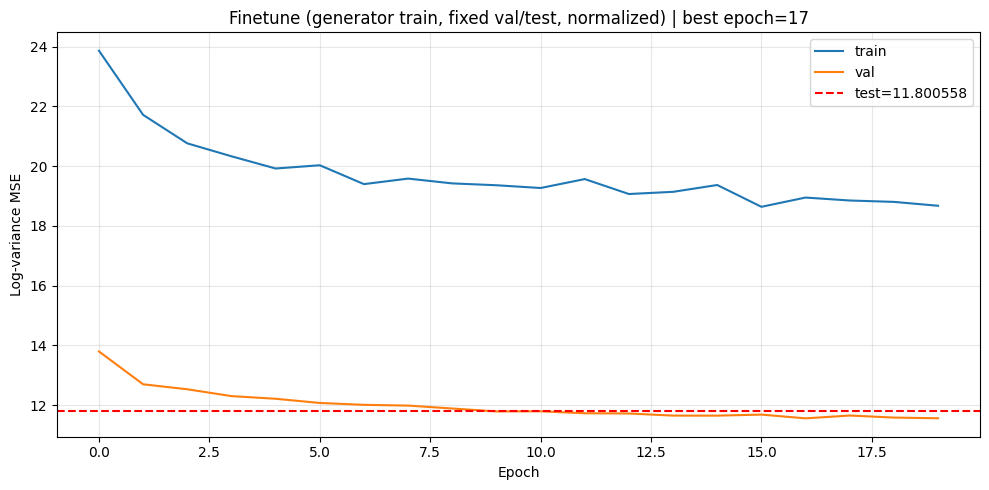

In [25]:
# --- Finetune prof-compliant: train generator + val/test fixes + normalization ---
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

from model import HybridGarch
from engine import train_hybrid_garch, eval_log_mse
from visualization import plot_training_curves

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

FT_EPOCHS = N_EPOCHS
FT_LR = 1e-4
FT_WD = 1e-6
PRETRAIN_PATH = "hybrid_garch_pretrained_synth_full.pt"

N_VAL = VAL_STEPS * BATCH_SIZE
N_TEST = TEST_STEPS * BATCH_SIZE

# train stats only (normalization)
train_block = returns_values[TRAIN_RANGE[0]:TRAIN_RANGE[1], :]
mean_train = float(train_block.mean())
std_train = float(train_block.std() + 1e-8)
var_scale = std_train ** 2

def make_train_generator_norm(values, start_idx, end_idx, window_size, batch_size, seed, mean_r, std_r):
    n_time, n_tickers = values.shape
    min_t = start_idx + window_size
    if min_t >= end_idx:
        raise ValueError(f"Range [{start_idx},{end_idx}) too short for window_size={window_size}")

    rng = np.random.default_rng(seed)
    s2 = std_r ** 2

    def _generator():
        while True:
            # subsample indices at each batch (as requested)
            t_idx = rng.integers(low=min_t, high=end_idx, size=batch_size)
            j_idx = rng.integers(low=0, high=n_tickers, size=batch_size)

            x = np.empty((batch_size, window_size, 1), dtype=np.float32)
            y = np.empty((batch_size,), dtype=np.float32)

            for i, (t, j) in enumerate(zip(t_idx, j_idx)):
                w = values[t - window_size:t, j]
                x[i, :, 0] = (w - mean_r) / std_r
                y[i] = (values[t, j] ** 2) / s2  # normalized variance proxy

            yield x, y

    return _generator

class TorchIterableFromNumpyGenerator:
    def __init__(self, gen_fn, steps_per_epoch):
        self.gen_fn = gen_fn
        self.steps_per_epoch = int(steps_per_epoch)

    def __iter__(self):
        it = self.gen_fn()
        for _ in range(self.steps_per_epoch):
            xb, yb = next(it)
            yield torch.from_numpy(xb), torch.from_numpy(yb)

    def __len__(self):
        return self.steps_per_epoch

def build_fixed_loader_norm(values, start_idx, end_idx, n_samples, window_size, batch_size, seed, mean_r, std_r):
    n_time, n_tickers = values.shape
    min_t = start_idx + window_size
    if min_t >= end_idx:
        raise ValueError(f"Range [{start_idx},{end_idx}) too short for window_size={window_size}")

    rng = np.random.default_rng(seed)
    t_idx = rng.integers(low=min_t, high=end_idx, size=n_samples)
    j_idx = rng.integers(low=0, high=n_tickers, size=n_samples)

    x = np.empty((n_samples, window_size, 1), dtype=np.float32)
    y = np.empty((n_samples,), dtype=np.float32)

    s2 = std_r ** 2
    for i, (t, j) in enumerate(zip(t_idx, j_idx)):
        w = values[t - window_size:t, j]
        x[i, :, 0] = (w - mean_r) / std_r
        y[i] = (values[t, j] ** 2) / s2

    ds = TensorDataset(torch.from_numpy(x), torch.from_numpy(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=False, drop_last=True)

# train via generator
train_gen_fn = make_train_generator_norm(
    returns_values, *TRAIN_RANGE,
    window_size=WINDOW_SIZE, batch_size=BATCH_SIZE,
    seed=SEED, mean_r=mean_train, std_r=std_train
)
train_loader = TorchIterableFromNumpyGenerator(train_gen_fn, TRAIN_STEPS)

# val/test fixed
val_loader = build_fixed_loader_norm(
    returns_values, *VAL_RANGE, n_samples=N_VAL,
    window_size=WINDOW_SIZE, batch_size=BATCH_SIZE,
    seed=SEED + 1, mean_r=mean_train, std_r=std_train
)
test_loader = build_fixed_loader_norm(
    returns_values, *TEST_RANGE, n_samples=N_TEST,
    window_size=WINDOW_SIZE, batch_size=BATCH_SIZE,
    seed=SEED + 2, mean_r=mean_train, std_r=std_train
)

# model + correct pretrained load
model_ft = HybridGarch(hidden=32).to(device)
ckpt = torch.load(PRETRAIN_PATH, map_location=device)
state = ckpt["model_state"] if isinstance(ckpt, dict) and "model_state" in ckpt else ckpt
incompat = model_ft.load_state_dict(state, strict=True)
print("Missing:", len(incompat.missing_keys), "Unexpected:", len(incompat.unexpected_keys))

# before finetune
test_before = eval_log_mse(model_ft, test_loader, device)
print(f"Test log-MSE before finetune: {test_before:.6f}")

# finetune
history_ft = train_hybrid_garch(
    model=model_ft,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=FT_EPOCHS,
    lr=FT_LR,
    device=device,
    ckpt_path="finetune_real_fixednorm_best.pt",
    weight_decay=FT_WD,
    scheduler_patience=2,
)

# after finetune
test_after = eval_log_mse(model_ft, test_loader, device)
best_ep = int(np.argmin(history_ft["val_loss"])) + 1
best_val = float(np.min(history_ft["val_loss"]))

print(f"Best val epoch: {best_ep} | best val loss: {best_val:.6f}")
print(f"Test log-MSE after finetune: {test_after:.6f}")

plot_training_curves(
    history_ft,
    test_loss=test_after,
    title=f"Finetune (generator train, fixed val/test, normalized) | best epoch={best_ep}"
)


scratch_real_best.pt | missing=0 unexpected=0
finetune_real_fixednorm_best.pt | missing=0 unexpected=0
ARCH progress: 100/800
ARCH progress: 200/800
ARCH progress: 300/800
ARCH progress: 400/800
ARCH progress: 500/800
ARCH progress: 600/800
ARCH progress: 700/800
ARCH progress: 800/800


,log_mse,corr_log,p_corr_log,spearman_rho_log,p_spearman,qlike,mse_level,mae_level,r2_level,r2_log,pred_over_r2,n_eval,p_logmse_vs_arch,p_qlike_vs_arch
finetune,15.412438,0.249083,8.864969e-13,0.270827,6.476985e-15,8.942310e+00,0.000003,0.000418,-0.032765,0.060098,0.156750,800.0,3.175928e-09,1.617002e-02
arch_garch11,21.159755,0.097149,5.959572e-03,0.265954,2.029898e-14,-7.079896e+00,0.000003,0.000576,-0.169777,-0.290392,1.229483,800.0,NaN,NaN
ewma_094,21.175308,0.093997,7.805750e-03,0.266699,1.707055e-14,-7.086727e+00,0.000003,0.000562,-0.009675,-0.291340,1.197547,800.0,9.078002e-01,8.129032e-01
scratch,22.092133,0.094181,7.685089e-03,0.200518,1.060042e-08,1.106965e+02,0.000003,0.000438,-0.061287,-0.347251,0.059493,800.0,4.693348e-01,2.769697e-18
naive_rtm1_sq,26.155993,0.117530,8.666154e-04,0.191898,4.496970e-08,6.280697e+06,0.000006,0.000656,-1.191395,-0.595079,1.087790,800.0,1.231706e-02,2.925368e-02
const,30.401566,NaN,NaN,NaN,NaN,-6.162824e+00,0.000004,0.001471,-0.520300,-0.853988,3.569304,800.0,6.620039e-51,7.899969e-41


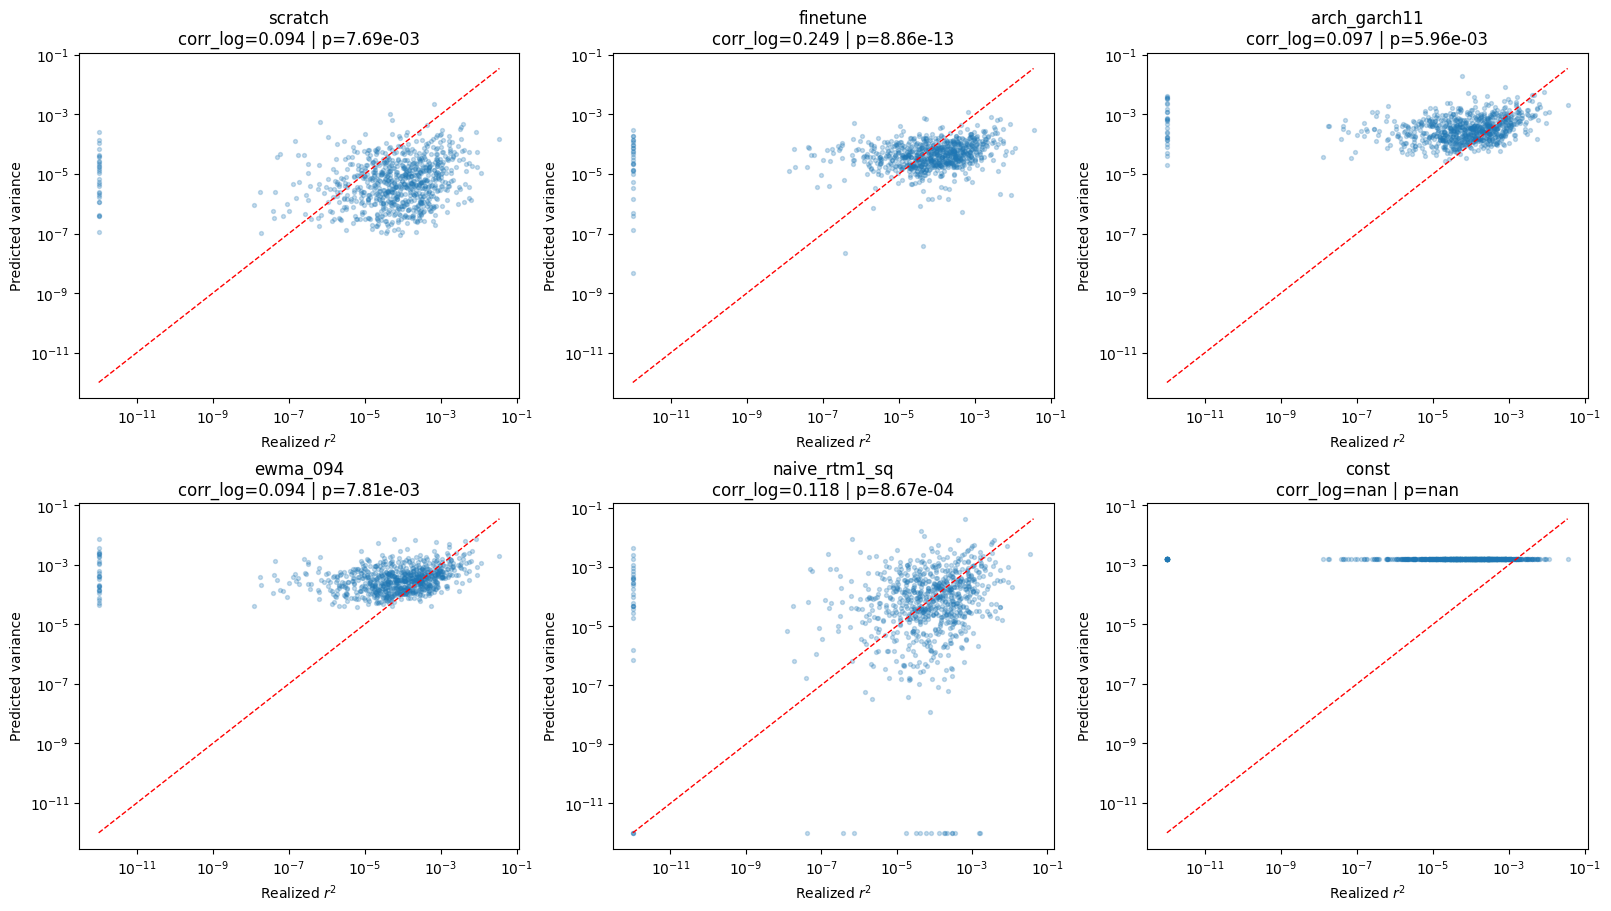

In [10]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr, spearmanr, ttest_rel
from arch import arch_model

from model import HybridGarch

# =========================
# Config
# =========================
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

SCRATCH_CKPT = "scratch_real_best.pt"
FINETUNE_CKPT = "finetune_real_fixednorm_best.pt"  # fallback ci-dessous
if not Path(FINETUNE_CKPT).exists():
    FINETUNE_CKPT = "finetune_real_best.pt"

# Si tes 2 modèles ont été entraînés avec x standardisé et y=r²/std² -> True
SCRATCH_INPUT_NORMALIZED = True
SCRATCH_OUTPUT_NORMALIZED = True
FINETUNE_INPUT_NORMALIZED = True
FINETUNE_OUTPUT_NORMALIZED = True

# Taille d'éval
N_EVAL = min(5000, BATCH_SIZE * TEST_STEPS)  # points totaux
N_ARCH = min(800, N_EVAL)                    # ARCH est coûteux
LAMBDA_EWMA = 0.94

# =========================
# Data fixed eval sample
# =========================
train_block = returns_values[TRAIN_RANGE[0]:TRAIN_RANGE[1], :]
mean_train = float(train_block.mean())
std_train = float(train_block.std() + 1e-8)
var_scale = std_train ** 2

def build_fixed_eval(values, split_range, window_size, n_samples, seed=42):
    start_idx, end_idx = split_range
    n_time, n_tickers = values.shape
    min_t = start_idx + window_size
    if min_t >= end_idx:
        raise ValueError("Split too short for window_size.")

    rng = np.random.default_rng(seed)
    t_idx = rng.integers(low=min_t, high=end_idx, size=n_samples)
    j_idx = rng.integers(low=0, high=n_tickers, size=n_samples)

    X_raw = np.empty((n_samples, window_size), dtype=np.float64)
    y_r2 = np.empty((n_samples,), dtype=np.float64)

    for i, (t, j) in enumerate(zip(t_idx, j_idx)):
        w = values[t - window_size:t, j]
        X_raw[i] = w
        y_r2[i] = values[t, j] ** 2

    return X_raw, y_r2, t_idx, j_idx

X_raw, y_true, t_idx, j_idx = build_fixed_eval(
    returns_values, TEST_RANGE, WINDOW_SIZE, N_EVAL, seed=SEED + 2
)

# =========================
# Load models + predict
# =========================
def load_hybrid(path):
    m = HybridGarch(hidden=32).to(device)
    ckpt = torch.load(path, map_location=device)
    state = ckpt["model_state"] if isinstance(ckpt, dict) and "model_state" in ckpt else ckpt
    incompat = m.load_state_dict(state, strict=False)
    print(f"{path} | missing={len(incompat.missing_keys)} unexpected={len(incompat.unexpected_keys)}")
    m.eval()
    return m

@torch.no_grad()
def predict_nn_variance(
    model,
    X_raw,
    mean_r,
    std_r,
    normalize_input=True,
    output_is_normalized=True,
    batch_size=2048,
):
    n = X_raw.shape[0]
    preds = np.empty(n, dtype=np.float64)
    scale_out = (std_r ** 2) if output_is_normalized else 1.0

    for i in range(0, n, batch_size):
        xb = X_raw[i:i+batch_size].copy()
        if normalize_input:
            xb = (xb - mean_r) / (std_r + 1e-8)
        xb = xb.astype(np.float32)[..., None]  # [B,W,1]
        xb = torch.from_numpy(xb).to(device)

        out = model(xb)
        s2 = out[0] if isinstance(out, (tuple, list)) else out
        preds[i:i+len(s2)] = s2.detach().cpu().numpy().reshape(-1) * scale_out

    return np.maximum(preds, 1e-12)

scratch_model = load_hybrid(SCRATCH_CKPT)
finetune_model = load_hybrid(FINETUNE_CKPT)

p_s = predict_nn_variance(
    scratch_model, X_raw, mean_train, std_train,
    normalize_input=SCRATCH_INPUT_NORMALIZED,
    output_is_normalized=SCRATCH_OUTPUT_NORMALIZED
)
p_f = predict_nn_variance(
    finetune_model, X_raw, mean_train, std_train,
    normalize_input=FINETUNE_INPUT_NORMALIZED,
    output_is_normalized=FINETUNE_OUTPUT_NORMALIZED
)

# =========================
# Baselines (all on same X_raw, y_true)
# =========================
const_var = float(np.mean(train_block.astype(np.float64) ** 2))
p_const = np.full_like(y_true, const_var)

p_naive = np.maximum(X_raw[:, -1] ** 2, 1e-12)

w = (1 - LAMBDA_EWMA) * (LAMBDA_EWMA ** np.arange(WINDOW_SIZE - 1, -1, -1))
w = w / w.sum()
p_ewma = np.maximum((X_raw ** 2) @ w, 1e-12)

# ARCH on subset (for speed)
rng = np.random.default_rng(SEED)
idx_arch = rng.choice(len(y_true), size=N_ARCH, replace=False)

def arch_1step(window_r):
    am = arch_model(window_r * 100.0, mean="Zero", vol="GARCH", p=1, q=1, dist="normal")
    res = am.fit(disp="off")
    f = res.forecast(horizon=1, reindex=False)
    return float(f.variance.values[-1, 0] / (100.0 ** 2))

p_arch = np.empty(N_ARCH, dtype=np.float64)
for k, i in enumerate(idx_arch):
    p_arch[k] = max(arch_1step(X_raw[i]), 1e-12)
    if (k + 1) % 100 == 0:
        print(f"ARCH progress: {k+1}/{N_ARCH}")

# Compare all models on same subset as ARCH
y_eval = np.maximum(y_true[idx_arch], 1e-12)
preds = {
    "scratch": np.maximum(p_s[idx_arch], 1e-12),
    "finetune": np.maximum(p_f[idx_arch], 1e-12),
    "arch_garch11": np.maximum(p_arch, 1e-12),
    "ewma_094": np.maximum(p_ewma[idx_arch], 1e-12),
    "naive_rtm1_sq": np.maximum(p_naive[idx_arch], 1e-12),
    "const": np.maximum(p_const[idx_arch], 1e-12),
}

# =========================
# Metrics + p-values
# =========================
def compute_metrics(y, p, eps=1e-12):
    y = np.maximum(y, eps)
    p = np.maximum(p, eps)

    ly = np.log(y)
    lp = np.log(p)

    log_sq_err = (lp - ly) ** 2
    qlike_terms = y / p + np.log(p)

    corr_ok = (np.std(ly) > 1e-14) and (np.std(lp) > 1e-14)
    if corr_ok:
        corr_log, p_corr_log = pearsonr(ly, lp)
        rho_log, p_spear = spearmanr(ly, lp)
    else:
        corr_log, p_corr_log, rho_log, p_spear = np.nan, np.nan, np.nan, np.nan

    # R2 in level and log-space
    den_lvl = np.sum((y - y.mean()) ** 2)
    den_log = np.sum((ly - ly.mean()) ** 2)
    r2_level = 1.0 - np.sum((p - y) ** 2) / den_lvl if den_lvl > 0 else np.nan
    r2_log = 1.0 - np.sum((lp - ly) ** 2) / den_log if den_log > 0 else np.nan

    out = {
        "log_mse": float(np.mean(log_sq_err)),
        "corr_log": float(corr_log) if np.isfinite(corr_log) else np.nan,
        "p_corr_log": float(p_corr_log) if np.isfinite(p_corr_log) else np.nan,
        "spearman_rho_log": float(rho_log) if np.isfinite(rho_log) else np.nan,
        "p_spearman": float(p_spear) if np.isfinite(p_spear) else np.nan,
        "qlike": float(np.mean(qlike_terms)),
        "mse_level": float(np.mean((p - y) ** 2)),
        "mae_level": float(np.mean(np.abs(p - y))),
        "r2_level": float(r2_level) if np.isfinite(r2_level) else np.nan,
        "r2_log": float(r2_log) if np.isfinite(r2_log) else np.nan,
        "pred_over_r2": float(np.mean(p) / np.mean(y)),
        "n_eval": int(len(y)),
    }
    return out, log_sq_err, qlike_terms

rows = {}
cache = {}
for name, p in preds.items():
    m, log_sq_err, qlike_terms = compute_metrics(y_eval, p)
    rows[name] = m
    cache[name] = {"log_sq_err": log_sq_err, "qlike_terms": qlike_terms}

# Paired p-values vs ARCH baseline
ref = "arch_garch11"
for name in rows.keys():
    if name == ref:
        rows[name]["p_logmse_vs_arch"] = np.nan
        rows[name]["p_qlike_vs_arch"] = np.nan
    else:
        rows[name]["p_logmse_vs_arch"] = float(
            ttest_rel(cache[name]["log_sq_err"], cache[ref]["log_sq_err"], alternative="two-sided").pvalue
        )
        rows[name]["p_qlike_vs_arch"] = float(
            ttest_rel(cache[name]["qlike_terms"], cache[ref]["qlike_terms"], alternative="two-sided").pvalue
        )

df_cmp = pd.DataFrame(rows).T.sort_values("log_mse")
display(df_cmp)

# =========================
# Plots: pred vs r²
# =========================
plot_order = ["scratch", "finetune", "arch_garch11", "ewma_094", "naive_rtm1_sq", "const"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

rng_plot = np.random.default_rng(SEED)
idx_plot = rng_plot.choice(len(y_eval), size=min(2000, len(y_eval)), replace=False)
y_plot = y_eval[idx_plot]

for ax, name in zip(axes.ravel(), plot_order):
    p_plot = preds[name][idx_plot]
    ax.scatter(y_plot, p_plot, s=8, alpha=0.25)

    lo = max(min(y_plot.min(), p_plot.min()), 1e-12)
    hi = max(y_plot.max(), p_plot.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Realized $r^2$")
    ax.set_ylabel("Predicted variance")

    c = df_cmp.loc[name, "corr_log"]
    pval = df_cmp.loc[name, "p_corr_log"]
    ax.set_title(f"{name}\ncorr_log={c:.3f} | p={pval:.2e}")

plt.show()


In [11]:
# =========================
# Robust eval (level + log) with zero handling
# =========================
from scipy.stats import pearsonr, spearmanr, ttest_rel
# juste avant compute_metrics sur subset ARCH


EPS = 1e-12
ZERO_RATIO_MAX = 0.20  # max 20% de zéros dans la fenêtre de calibration

# Subset commun (ARCH) + cast float32 (cohérent NN)
y_arch = y_true[idx_arch].astype(np.float32)          # realized r^2 (t+1)
X_arch = X_raw[idx_arch].astype(np.float32)           # fenêtres de calibration

preds_arch = {
    "scratch": p_s[idx_arch].astype(np.float32),
    "finetune": p_f[idx_arch].astype(np.float32),
    "arch_garch11": p_arch.astype(np.float32),
    "ewma_094": p_ewma[idx_arch].astype(np.float32),
    "naive_rtm1_sq": p_naive[idx_arch].astype(np.float32),
    "const": p_const[idx_arch].astype(np.float32),
}

# 1) Exclure OOS avec r_{t+1}=0
mask_oos_nonzero = (y_arch != 0.0)

# 2) Exclure fenêtres avec trop de zéros
zero_ratio = (X_arch == 0.0).mean(axis=1)
mask_window_ok = zero_ratio <= ZERO_RATIO_MAX

mask_keep = mask_oos_nonzero & mask_window_ok

y_eval = y_arch[mask_keep]
preds_eval = {k: v[mask_keep] for k, v in preds_arch.items()}

print(f"Kept samples: {len(y_eval)}/{len(y_arch)} "
      f"({100*len(y_eval)/max(1,len(y_arch)):.1f}%)")

def _safe_pearson(x, y):
    if len(x) < 3 or np.std(x) < 1e-14 or np.std(y) < 1e-14:
        return np.nan, np.nan
    r, p = pearsonr(x, y)
    return float(r), float(p)

def _safe_spearman(x, y):
    if len(x) < 3:
        return np.nan, np.nan
    r, p = spearmanr(x, y)
    return float(r), float(p)

def compute_metrics_robust(y, p, eps=1e-12):
    y = y.astype(np.float32)
    p = p.astype(np.float32)

    p_pos = np.maximum(p, eps)  # sécurité pour log(p) / division
    mask_log = y >= eps         # IMPORTANT: log metrics uniquement si y>=eps

    # --- Level metrics (non-log) ---
    corr_lvl, p_corr_lvl = _safe_pearson(y, p_pos)
    rho_lvl, p_spear_lvl = _safe_spearman(y, p_pos)

    den_lvl = np.sum((y - y.mean()) ** 2)
    r2_level = 1.0 - np.sum((p_pos - y) ** 2) / den_lvl if den_lvl > 0 else np.nan

    # --- Log metrics (filtre y<eps) ---
    y_log = y[mask_log]
    p_log = p_pos[mask_log]

    if len(y_log) >= 3:
        ly = np.log(y_log)
        lp = np.log(p_log)

        log_sq_err = (lp - ly) ** 2
        corr_log, p_corr_log = _safe_pearson(ly, lp)
        rho_log, p_spear_log = _safe_spearman(ly, lp)

        den_log = np.sum((ly - ly.mean()) ** 2)
        r2_log = 1.0 - np.sum((lp - ly) ** 2) / den_log if den_log > 0 else np.nan
        log_mse = float(np.mean(log_sq_err))
    else:
        ly = lp = log_sq_err = np.array([], dtype=np.float32)
        corr_log = p_corr_log = rho_log = p_spear_log = np.nan
        r2_log = np.nan
        log_mse = np.nan

    # QLIKE (défini tant que p>0)
    qlike_terms = (y / p_pos) + np.log(p_pos)

    out = {
        "n_eval": int(len(y)),
        "n_log_eval": int(mask_log.sum()),
        "zero_ratio_max": ZERO_RATIO_MAX,
        "eps_log": eps,

        "mse_level": float(np.mean((p_pos - y) ** 2)),
        "mae_level": float(np.mean(np.abs(p_pos - y))),
        "r2_level": float(r2_level) if np.isfinite(r2_level) else np.nan,
        "corr_level": corr_lvl,
        "p_corr_level": p_corr_lvl,
        "spearman_rho_level": rho_lvl,
        "p_spearman_level": p_spear_lvl,

        "log_mse": log_mse,
        "r2_log": float(r2_log) if np.isfinite(r2_log) else np.nan,
        "corr_log": corr_log,
        "p_corr_log": p_corr_log,
        "spearman_rho_log": rho_log,
        "p_spearman_log": p_spear_log,

        "qlike": float(np.mean(qlike_terms)),
        "pred_over_r2": float(np.mean(p_pos) / max(np.mean(y), eps)),
    }
    return out, log_sq_err, qlike_terms

rows = {}
cache = {}
for name, p in preds_eval.items():
    m, log_sq_err, qlike_terms = compute_metrics_robust(y_eval, p, eps=EPS)
    rows[name] = m
    cache[name] = {"log_sq_err": log_sq_err, "qlike_terms": qlike_terms}

# Paired p-values vs ARCH
ref = "arch_garch11"
for name in rows:
    if name == ref:
        rows[name]["p_logmse_vs_arch"] = np.nan
        rows[name]["p_qlike_vs_arch"] = np.nan
        continue

    # log-MSE p-value (seulement si assez de points log valides)
    a = cache[name]["log_sq_err"]
    b = cache[ref]["log_sq_err"]
    if len(a) >= 3 and len(b) >= 3 and len(a) == len(b):
        rows[name]["p_logmse_vs_arch"] = float(ttest_rel(a, b, alternative="two-sided").pvalue)
    else:
        rows[name]["p_logmse_vs_arch"] = np.nan

    # QLIKE p-value
    qa = cache[name]["qlike_terms"]
    qb = cache[ref]["qlike_terms"]
    if len(qa) >= 3 and len(qb) >= 3 and len(qa) == len(qb):
        rows[name]["p_qlike_vs_arch"] = float(ttest_rel(qa, qb, alternative="two-sided").pvalue)
    else:
        rows[name]["p_qlike_vs_arch"] = np.nan

df_cmp_robust = pd.DataFrame(rows).T.sort_values("log_mse", na_position="last")
display(df_cmp_robust)



Kept samples: 759/800 (94.9%)


C:\Users\karim\AppData\Local\Temp\ipykernel_24332\1454971584.py:42: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(x, y)
C:\Users\karim\AppData\Local\Temp\ipykernel_24332\1454971584.py:48: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(x, y)


,n_eval,n_log_eval,zero_ratio_max,eps_log,mse_level,mae_level,r2_level,corr_level,p_corr_level,spearman_rho_level,...,log_mse,r2_log,corr_log,p_corr_log,spearman_rho_log,p_spearman_log,qlike,pred_over_r2,p_logmse_vs_arch,p_qlike_vs_arch
finetune,759.0,759.0,0.2,1.000000e-12,0.000003,0.000417,-0.030887,0.243370,1.074068e-11,0.292840,...,5.157921,-0.020614,0.253698,1.300576e-12,0.292840,1.786073e-16,6.533617e-01,0.158667,6.334930e-07,9.876185e-05
arch_garch11,759.0,759.0,0.2,1.000000e-12,0.000003,0.000542,-0.142309,0.191490,1.059990e-07,0.307642,...,6.806590,-0.346841,0.307330,4.574127e-18,0.307642,4.218218e-18,-7.078597e+00,1.166778,NaN,NaN
ewma_094,759.0,759.0,0.2,1.000000e-12,0.000002,0.000519,0.062422,0.288621,4.994460e-16,0.304821,...,6.844043,-0.354252,0.296733,6.808681e-17,0.304821,8.757426e-18,-7.095027e+00,1.117137,6.600789e-01,5.808440e-01
scratch,759.0,759.0,0.2,1.000000e-12,0.000003,0.000439,-0.061464,0.101322,5.205810e-03,0.233940,...,13.204041,-1.612724,0.237649,3.319107e-11,0.233940,6.792870e-11,1.119118e+02,0.058463,1.048930e-17,5.303450e-18
naive_rtm1_sq,759.0,759.0,0.2,1.000000e-12,0.000006,0.000641,-1.226808,0.101042,5.332012e-03,0.226136,...,14.145958,-1.799104,0.169292,2.729338e-06,0.226136,2.946619e-10,4.655380e+06,1.066796,2.248523e-05,4.454047e-02
const,759.0,759.0,0.2,1.000000e-12,0.000004,0.001459,-0.516708,NaN,NaN,NaN,...,14.637441,-1.896355,NaN,NaN,NaN,NaN,-6.161454e+00,3.551940,2.130938e-92,2.996546e-38


# Filter zero return and treshold <20% in window 90 days

Missing: 0 Unexpected: 0
Test log-MSE before finetune: 6.351578
Epoch 01 | train=4.999888 | val=4.638705 | alpha=0.0621 beta=0.8112
Epoch 02 | train=4.430856 | val=4.473031 | alpha=0.0353 beta=0.8285
Epoch 04 | train=4.362472 | val=4.428487 | alpha=0.0288 beta=0.7936
Epoch 06 | train=4.432653 | val=4.429116 | alpha=0.0287 beta=0.7564
Epoch 08 | train=4.354248 | val=4.419711 | alpha=0.0299 beta=0.7303
Epoch 10 | train=4.324937 | val=4.425769 | alpha=0.0303 beta=0.7035
Epoch 12 | train=4.345665 | val=4.427089 | alpha=0.0331 beta=0.6762
Epoch 14 | train=4.392500 | val=4.413225 | alpha=0.0332 beta=0.6667
Epoch 16 | train=4.423359 | val=4.408738 | alpha=0.0313 beta=0.6625
Epoch 18 | train=4.377999 | val=4.417592 | alpha=0.0338 beta=0.6437
Epoch 20 | train=4.375853 | val=4.418264 | alpha=0.0332 beta=0.6291
Best val loss = 4.407984 (log-variance MSE)
Best val epoch: 17 | best val loss: 4.407984
Test log-MSE after finetune: 4.415405


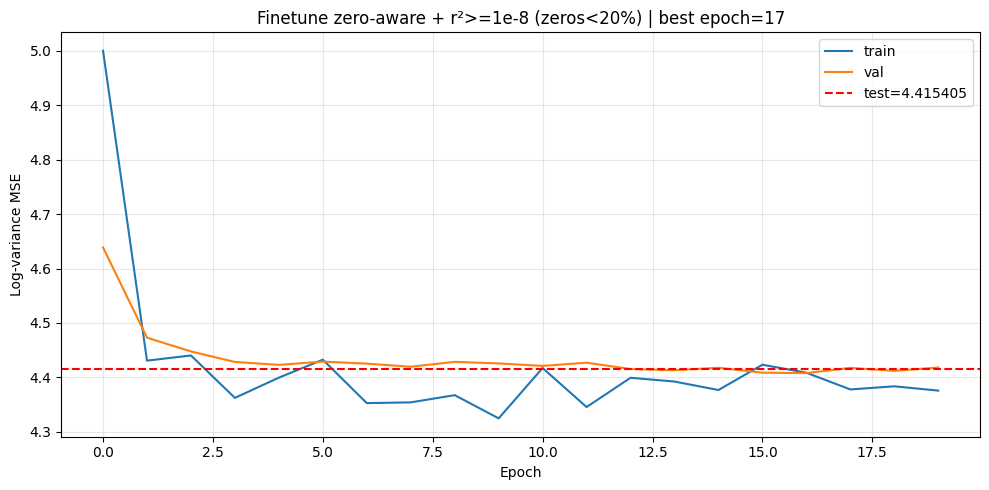

In [16]:
# --- Finetune with zero-aware + r² floor filtering ---
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

from model import HybridGarch
from engine import train_hybrid_garch, eval_log_mse
from visualization import plot_training_curves

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

FT_EPOCHS = N_EPOCHS
FT_LR = 1e-4
FT_WD = 1e-6
PRETRAIN_PATH = "hybrid_garch_pretrained_synth_full.pt"

# Filtering constraints
ZERO_RATIO_MAX = 0.20              # calibration window: < 20% zeros
R2_MIN = np.float32(1e-8)          # keep only samples with realized r² >= 1e-8
DRAW_MULT = 4
MAX_ATTEMPTS_FACTOR = 200

N_VAL = VAL_STEPS * BATCH_SIZE
N_TEST = TEST_STEPS * BATCH_SIZE

# train stats only (normalization)
train_block = returns_values[TRAIN_RANGE[0]:TRAIN_RANGE[1], :]
mean_train = float(train_block.mean())
std_train = float(train_block.std() + 1e-8)

def _is_valid_sample(values, t, j, window_size, zero_ratio_max, r2_min):
    # Realized return and realized r² in float32
    r_next = np.float32(values[t, j])
    r2 = np.float32(r_next * r_next)

    # Exclude tiny/zero realized r²
    if r2 < r2_min:
        return False

    # Fewer than 20% zeros in calibration window
    w = values[t - window_size:t, j]
    return (w == 0.0).mean() < zero_ratio_max

def make_train_generator_norm_filtered(
    values, start_idx, end_idx, window_size, batch_size, seed,
    mean_r, std_r, zero_ratio_max=0.20, r2_min=np.float32(1e-8)
):
    n_time, n_tickers = values.shape
    min_t = start_idx + window_size
    if min_t >= end_idx:
        raise ValueError(f"Range [{start_idx},{end_idx}) too short for window_size={window_size}")

    rng = np.random.default_rng(seed)
    std_r32 = np.float32(std_r)
    mean_r32 = np.float32(mean_r)
    s2_local = np.float32(std_r * std_r)

    def _generator():
        while True:
            x = np.empty((batch_size, window_size, 1), dtype=np.float32)
            y = np.empty((batch_size,), dtype=np.float32)

            filled = 0
            attempts = 0
            max_attempts = MAX_ATTEMPTS_FACTOR * batch_size

            while filled < batch_size:
                need = batch_size - filled
                draw = max(need * DRAW_MULT, 128)

                t_idx = rng.integers(low=min_t, high=end_idx, size=draw)
                j_idx = rng.integers(low=0, high=n_tickers, size=draw)

                for t, j in zip(t_idx, j_idx):
                    attempts += 1
                    if attempts > max_attempts:
                        raise RuntimeError(
                            "Too many rejected samples in train generator. "
                            "Try relaxing ZERO_RATIO_MAX / R2_MIN or using a wider split."
                        )

                    if not _is_valid_sample(values, t, j, window_size, zero_ratio_max, r2_min):
                        continue

                    w = values[t - window_size:t, j].astype(np.float32)
                    r_next = np.float32(values[t, j])
                    r2 = np.float32(r_next * r_next)  # float32 realized r²

                    x[filled, :, 0] = (w - mean_r32) / std_r32
                    y[filled] = np.float32(r2 / s2_local)  # normalized target

                    filled += 1
                    if filled == batch_size:
                        break

            yield x, y

    return _generator

class TorchIterableFromNumpyGenerator:
    def __init__(self, gen_fn, steps_per_epoch):
        self.gen_fn = gen_fn
        self.steps_per_epoch = int(steps_per_epoch)

    def __iter__(self):
        it = self.gen_fn()
        for _ in range(self.steps_per_epoch):
            xb, yb = next(it)
            yield torch.from_numpy(xb), torch.from_numpy(yb)

    def __len__(self):
        return self.steps_per_epoch

def build_fixed_loader_norm_filtered(
    values, start_idx, end_idx, n_samples, window_size, batch_size, seed,
    mean_r, std_r, zero_ratio_max=0.20, r2_min=np.float32(1e-8)
):
    n_time, n_tickers = values.shape
    min_t = start_idx + window_size
    if min_t >= end_idx:
        raise ValueError(f"Range [{start_idx},{end_idx}) too short for window_size={window_size}")

    rng = np.random.default_rng(seed)
    std_r32 = np.float32(std_r)
    mean_r32 = np.float32(mean_r)
    s2_local = np.float32(std_r * std_r)

    x = np.empty((n_samples, window_size, 1), dtype=np.float32)
    y = np.empty((n_samples,), dtype=np.float32)

    filled = 0
    attempts = 0
    max_attempts = MAX_ATTEMPTS_FACTOR * n_samples

    while filled < n_samples:
        need = n_samples - filled
        draw = max(need * DRAW_MULT, 256)

        t_idx = rng.integers(low=min_t, high=end_idx, size=draw)
        j_idx = rng.integers(low=0, high=n_tickers, size=draw)

        for t, j in zip(t_idx, j_idx):
            attempts += 1
            if attempts > max_attempts:
                raise RuntimeError(
                    "Too many rejected samples in fixed loader. "
                    "Try relaxing ZERO_RATIO_MAX / R2_MIN or using a wider split."
                )

            if not _is_valid_sample(values, t, j, window_size, zero_ratio_max, r2_min):
                continue

            w = values[t - window_size:t, j].astype(np.float32)
            r_next = np.float32(values[t, j])
            r2 = np.float32(r_next * r_next)  # float32 realized r²

            x[filled, :, 0] = (w - mean_r32) / std_r32
            y[filled] = np.float32(r2 / s2_local)
            filled += 1
            if filled == n_samples:
                break

    ds = TensorDataset(torch.from_numpy(x), torch.from_numpy(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=False, drop_last=True)

# train via filtered generator
train_gen_fn = make_train_generator_norm_filtered(
    returns_values, *TRAIN_RANGE,
    window_size=WINDOW_SIZE, batch_size=BATCH_SIZE,
    seed=SEED, mean_r=mean_train, std_r=std_train,
    zero_ratio_max=ZERO_RATIO_MAX, r2_min=R2_MIN
)
train_loader = TorchIterableFromNumpyGenerator(train_gen_fn, TRAIN_STEPS)

# val/test fixed + same filtering
val_loader = build_fixed_loader_norm_filtered(
    returns_values, *VAL_RANGE, n_samples=N_VAL,
    window_size=WINDOW_SIZE, batch_size=BATCH_SIZE,
    seed=SEED + 1, mean_r=mean_train, std_r=std_train,
    zero_ratio_max=ZERO_RATIO_MAX, r2_min=R2_MIN
)
test_loader = build_fixed_loader_norm_filtered(
    returns_values, *TEST_RANGE, n_samples=N_TEST,
    window_size=WINDOW_SIZE, batch_size=BATCH_SIZE,
    seed=SEED + 2, mean_r=mean_train, std_r=std_train,
    zero_ratio_max=ZERO_RATIO_MAX, r2_min=R2_MIN
)

# model + pretrained load
model_ft = HybridGarch(hidden=32).to(device)
ckpt = torch.load(PRETRAIN_PATH, map_location=device)
state = ckpt["model_state"] if isinstance(ckpt, dict) and "model_state" in ckpt else ckpt
incompat = model_ft.load_state_dict(state, strict=True)
print("Missing:", len(incompat.missing_keys), "Unexpected:", len(incompat.unexpected_keys))

# before finetune
test_before = eval_log_mse(model_ft, test_loader, device)
print(f"Test log-MSE before finetune: {test_before:.6f}")

# finetune
history_ft = train_hybrid_garch(
    model=model_ft,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=FT_EPOCHS,
    lr=FT_LR,
    device=device,
    ckpt_path="finetune_real_zeroaware_r2min1e8_best.pt",
    weight_decay=FT_WD,
    scheduler_patience=2,
)

# after finetune
test_after = eval_log_mse(model_ft, test_loader, device)
best_ep = int(np.argmin(history_ft["val_loss"])) + 1
best_val = float(np.min(history_ft["val_loss"]))

print(f"Best val epoch: {best_ep} | best val loss: {best_val:.6f}")
print(f"Test log-MSE after finetune: {test_after:.6f}")

plot_training_curves(
    history_ft,
    test_loss=test_after,
    title=f"Finetune zero-aware + r²>=1e-8 (zeros<{ZERO_RATIO_MAX:.0%}) | best epoch={best_ep}"
)


scratch_real_best.pt | missing=0 unexpected=0
finetune_real_zeroaware_r2min1e8_best.pt | missing=0 unexpected=0
ARCH progress: 100/800
ARCH progress: 200/800


C:\Users\karim\AppData\Local\Temp\ipykernel_24332\1001113167.py:163: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  res = am.fit(disp="off")


ARCH progress: 300/800
ARCH progress: 400/800
ARCH progress: 500/800
ARCH progress: 600/800
ARCH progress: 700/800


C:\Users\karim\AppData\Local\Temp\ipykernel_24332\1001113167.py:163: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  res = am.fit(disp="off")


ARCH progress: 800/800
Kept after r²>=1e-8: 800/800


C:\Users\karim\AppData\Local\Temp\ipykernel_24332\1001113167.py:203: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(a, b)
C:\Users\karim\AppData\Local\Temp\ipykernel_24332\1001113167.py:197: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(a, b)


,n_eval,n_log_eval,zero_ratio_max,r2_min,eps_log,mse_level,mae_level,r2_level,corr_level,p_corr_level,...,log_mse,r2_log,corr_log,p_corr_log,spearman_rho_log,p_spearman_log,qlike,pred_over_r2,p_logmse_vs_arch,p_qlike_vs_arch
finetune_zeroaware,800.0,800.0,0.2,1.000000e-08,1.000000e-12,0.000001,0.000390,0.009742,0.327957,1.630877e-21,...,4.828360,0.088610,0.310001,2.795112e-19,0.346806,5.027124e-24,-5.521221e+00,0.286824,4.858654e-24,7.668720e-09
arch_garch11,800.0,800.0,0.2,1.000000e-08,1.000000e-12,0.000002,0.000516,-0.066136,0.256043,1.929607e-13,...,7.003564,-0.321977,0.321467,1.090009e-20,0.336666,1.185253e-22,-7.056545e+00,1.167408,NaN,NaN
ewma_094,800.0,800.0,0.2,1.000000e-08,1.000000e-12,0.000001,0.000490,0.072986,0.300521,3.677865e-18,...,7.006141,-0.322463,0.305791,8.881174e-19,0.337439,9.351816e-23,-7.025495e+00,1.069548,9.712246e-01,2.337104e-01
scratch,800.0,800.0,0.2,1.000000e-08,1.000000e-12,0.000002,0.000411,-0.090026,0.233425,2.317562e-11,...,12.951712,-1.444736,0.258620,1.084363e-13,0.245014,2.116535e-12,1.632531e+02,0.052639,3.423122e-15,6.688113e-06
const,800.0,800.0,0.2,1.000000e-08,1.000000e-12,0.000003,0.001426,-0.922198,NaN,NaN,...,15.123357,-1.854650,NaN,NaN,NaN,NaN,-6.176095e+00,3.746794,9.314960e-98,2.252658e-36
naive_rtm1_sq,800.0,800.0,0.2,1.000000e-08,1.000000e-12,0.000002,0.000550,-0.388101,0.221734,2.284689e-10,...,15.511842,-1.927980,0.161542,4.387034e-06,0.222806,1.861755e-10,7.311590e+06,0.948594,6.017404e-06,2.530178e-02


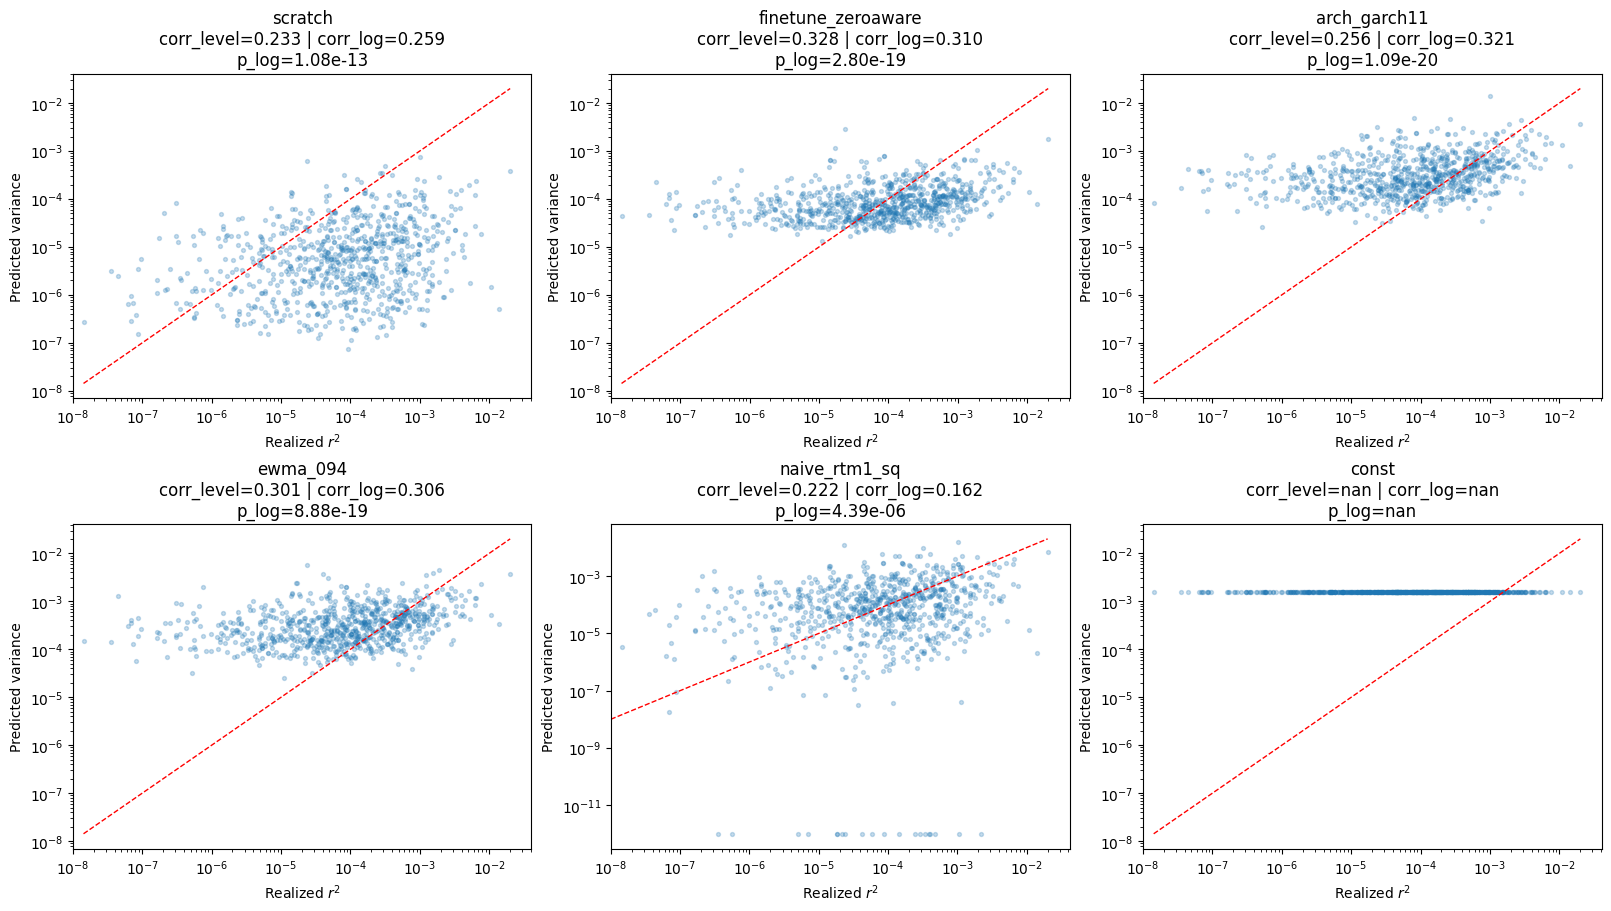

In [18]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr, spearmanr, ttest_rel
from arch import arch_model

from model import HybridGarch

# =========================
# Config
# =========================
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

EPS = 1e-12
R2_MIN = np.float32(1e-8)
ZERO_RATIO_MAX = 0.20
LAMBDA_EWMA = 0.94

SCRATCH_CKPT = "scratch_real_best.pt"
FINETUNE_CKPT = "finetune_real_zeroaware_r2min1e8_best.pt"
if not Path(FINETUNE_CKPT).exists():
    FINETUNE_CKPT = "finetune_real_zeroaware_best.pt"
if not Path(FINETUNE_CKPT).exists():
    FINETUNE_CKPT = "finetune_real_fixednorm_best.pt"
if not Path(FINETUNE_CKPT).exists():
    FINETUNE_CKPT = "finetune_real_best.pt"

SCRATCH_INPUT_NORMALIZED = True
SCRATCH_OUTPUT_NORMALIZED = True
FINETUNE_INPUT_NORMALIZED = True
FINETUNE_OUTPUT_NORMALIZED = True

N_EVAL = min(5000, BATCH_SIZE * TEST_STEPS)

# =========================
# Train stats (normalization)
# =========================
train_block = returns_values[TRAIN_RANGE[0]:TRAIN_RANGE[1], :]
mean_train = float(train_block.mean())
std_train = float(train_block.std() + 1e-8)

# =========================
# Fixed eval sample with filtering
# - r² >= 1e-8
# - calibration window zeros < 20%
# - float32 target
# =========================
def build_fixed_eval_filtered(values, split_range, window_size, n_samples, seed=42, zero_ratio_max=0.20):
    start_idx, end_idx = split_range
    n_time, n_tickers = values.shape
    min_t = start_idx + window_size
    if min_t >= end_idx:
        raise ValueError("Split too short for window_size.")

    rng = np.random.default_rng(seed)

    X_raw = np.empty((n_samples, window_size), dtype=np.float32)
    y_r2 = np.empty((n_samples,), dtype=np.float32)
    t_out = np.empty((n_samples,), dtype=np.int64)
    j_out = np.empty((n_samples,), dtype=np.int64)

    filled = 0
    attempts = 0
    max_attempts = 300 * n_samples

    while filled < n_samples:
        need = n_samples - filled
        draw = max(4 * need, 256)

        t_idx = rng.integers(low=min_t, high=end_idx, size=draw)
        j_idx = rng.integers(low=0, high=n_tickers, size=draw)

        for t, j in zip(t_idx, j_idx):
            attempts += 1
            if attempts > max_attempts:
                raise RuntimeError("Too many rejected samples. Try lowering N_EVAL or relaxing filters.")

            r_next = np.float32(values[t, j])
            r2 = np.float32(r_next * r_next)
            if r2 < R2_MIN:
                continue

            w = values[t - window_size:t, j].astype(np.float32)
            if (w == 0.0).mean() >= zero_ratio_max:
                continue

            X_raw[filled] = w
            y_r2[filled] = r2
            t_out[filled] = t
            j_out[filled] = j
            filled += 1
            if filled == n_samples:
                break

    return X_raw, y_r2, t_out, j_out

X_raw, y_true, t_idx, j_idx = build_fixed_eval_filtered(
    returns_values, TEST_RANGE, WINDOW_SIZE, N_EVAL, seed=SEED + 2, zero_ratio_max=ZERO_RATIO_MAX
)

N_ARCH = min(800, len(y_true))
if N_ARCH < 10:
    raise ValueError(f"Not enough filtered points ({N_ARCH}).")

# =========================
# Load models + predict
# =========================
def load_hybrid(path):
    m = HybridGarch(hidden=32).to(device)
    ckpt = torch.load(path, map_location=device)
    state = ckpt["model_state"] if isinstance(ckpt, dict) and "model_state" in ckpt else ckpt
    incompat = m.load_state_dict(state, strict=False)
    print(f"{path} | missing={len(incompat.missing_keys)} unexpected={len(incompat.unexpected_keys)}")
    m.eval()
    return m

@torch.no_grad()
def predict_nn_variance(model, X_raw, mean_r, std_r, normalize_input=True, output_is_normalized=True, batch_size=2048):
    n = X_raw.shape[0]
    preds = np.empty(n, dtype=np.float32)
    scale_out = np.float32((std_r ** 2) if output_is_normalized else 1.0)

    for i in range(0, n, batch_size):
        xb = X_raw[i:i+batch_size].copy()
        if normalize_input:
            xb = (xb - np.float32(mean_r)) / np.float32(std_r + 1e-8)
        xb = xb.astype(np.float32)[..., None]
        xb = torch.from_numpy(xb).to(device)

        out = model(xb)
        s2 = out[0] if isinstance(out, (tuple, list)) else out
        preds[i:i+len(s2)] = s2.detach().cpu().numpy().reshape(-1).astype(np.float32) * scale_out

    return np.maximum(preds, np.float32(EPS))

scratch_model = load_hybrid(SCRATCH_CKPT)
finetune_model = load_hybrid(FINETUNE_CKPT)

p_s = predict_nn_variance(scratch_model, X_raw, mean_train, std_train, SCRATCH_INPUT_NORMALIZED, SCRATCH_OUTPUT_NORMALIZED)
p_f = predict_nn_variance(finetune_model, X_raw, mean_train, std_train, FINETUNE_INPUT_NORMALIZED, FINETUNE_OUTPUT_NORMALIZED)

# =========================
# Baselines
# =========================
const_var = float(np.mean(train_block.astype(np.float64) ** 2))
p_const = np.full_like(y_true, np.float32(const_var), dtype=np.float32)
p_naive = np.maximum((X_raw[:, -1] ** 2).astype(np.float32), np.float32(EPS))

w = (1 - LAMBDA_EWMA) * (LAMBDA_EWMA ** np.arange(WINDOW_SIZE - 1, -1, -1))
w = (w / w.sum()).astype(np.float32)
p_ewma = np.maximum(((X_raw ** 2) @ w).astype(np.float32), np.float32(EPS))

# ARCH subset
rng = np.random.default_rng(SEED)
idx_arch = rng.choice(len(y_true), size=N_ARCH, replace=False)

def arch_1step(window_r):
    am = arch_model(window_r.astype(np.float64) * 100.0, mean="Zero", vol="GARCH", p=1, q=1, dist="normal")
    res = am.fit(disp="off")
    f = res.forecast(horizon=1, reindex=False)
    return float(f.variance.values[-1, 0] / (100.0 ** 2))

p_arch = np.empty(N_ARCH, dtype=np.float32)
for k, i in enumerate(idx_arch):
    p_arch[k] = np.float32(max(arch_1step(X_raw[i]), EPS))
    if (k + 1) % 100 == 0:
        print(f"ARCH progress: {k+1}/{N_ARCH}")

# Common eval arrays + safety mask r² >= 1e-8
y_eval = y_true[idx_arch].astype(np.float32)
preds = {
    "scratch": np.maximum(p_s[idx_arch], np.float32(EPS)),
    "finetune_zeroaware": np.maximum(p_f[idx_arch], np.float32(EPS)),
    "arch_garch11": np.maximum(p_arch, np.float32(EPS)),
    "ewma_094": np.maximum(p_ewma[idx_arch], np.float32(EPS)),
    "naive_rtm1_sq": np.maximum(p_naive[idx_arch], np.float32(EPS)),
    "const": np.maximum(p_const[idx_arch], np.float32(EPS)),
}

mask_r2 = y_eval >= R2_MIN
y_eval = y_eval[mask_r2]
for k in preds:
    preds[k] = preds[k][mask_r2]

print(f"Kept after r²>=1e-8: {len(y_eval)}/{len(mask_r2)}")

# =========================
# Metrics + p-values
# =========================
def _safe_pearson(a, b):
    if len(a) < 3 or np.std(a) < 1e-14 or np.std(b) < 1e-14:
        return np.nan, np.nan
    r, p = pearsonr(a, b)
    return float(r), float(p)

def _safe_spearman(a, b):
    if len(a) < 3:
        return np.nan, np.nan
    r, p = spearmanr(a, b)
    return float(r), float(p)

def compute_metrics(y, p, eps=1e-12):
    y = y.astype(np.float32)
    p = np.maximum(p.astype(np.float32), np.float32(eps))

    corr_level, p_corr_level = _safe_pearson(y, p)
    rho_level, p_spear_level = _safe_spearman(y, p)

    den_lvl = np.sum((y - y.mean()) ** 2)
    r2_level = 1.0 - np.sum((p - y) ** 2) / den_lvl if den_lvl > 0 else np.nan
    mse_level = float(np.mean((p - y) ** 2))
    mae_level = float(np.mean(np.abs(p - y)))

    mask_log = y >= max(np.float32(eps), R2_MIN)
    yl = y[mask_log]
    pl = p[mask_log]

    if len(yl) >= 3:
        ly = np.log(yl)
        lp = np.log(pl)
        log_sq_err = (lp - ly) ** 2
        qlike_terms = yl / pl + np.log(pl)

        corr_log, p_corr_log = _safe_pearson(ly, lp)
        rho_log, p_spear_log = _safe_spearman(ly, lp)

        den_log = np.sum((ly - ly.mean()) ** 2)
        r2_log = 1.0 - np.sum((lp - ly) ** 2) / den_log if den_log > 0 else np.nan
        log_mse = float(np.mean(log_sq_err))
        qlike = float(np.mean(qlike_terms))
    else:
        log_sq_err = np.array([], dtype=np.float32)
        qlike_terms = np.array([], dtype=np.float32)
        corr_log = p_corr_log = rho_log = p_spear_log = np.nan
        r2_log = np.nan
        log_mse = np.nan
        qlike = np.nan

    out = {
        "n_eval": int(len(y)),
        "n_log_eval": int(mask_log.sum()),
        "zero_ratio_max": float(ZERO_RATIO_MAX),
        "r2_min": float(R2_MIN),
        "eps_log": float(eps),
        "mse_level": mse_level,
        "mae_level": mae_level,
        "r2_level": float(r2_level) if np.isfinite(r2_level) else np.nan,
        "corr_level": corr_level,
        "p_corr_level": p_corr_level,
        "spearman_rho_level": rho_level,
        "p_spearman_level": p_spear_level,
        "log_mse": log_mse,
        "r2_log": float(r2_log) if np.isfinite(r2_log) else np.nan,
        "corr_log": corr_log,
        "p_corr_log": p_corr_log,
        "spearman_rho_log": rho_log,
        "p_spearman_log": p_spear_log,
        "qlike": qlike,
        "pred_over_r2": float(np.mean(p) / max(np.mean(y), eps)),
    }
    return out, log_sq_err, qlike_terms

rows, cache = {}, {}
for name, p in preds.items():
    m, log_sq_err, qlike_terms = compute_metrics(y_eval, p, eps=EPS)
    rows[name] = m
    cache[name] = {"log_sq_err": log_sq_err, "qlike_terms": qlike_terms}

ref = "arch_garch11"
for name in rows:
    if name == ref:
        rows[name]["p_logmse_vs_arch"] = np.nan
        rows[name]["p_qlike_vs_arch"] = np.nan
    else:
        a, b = cache[name]["log_sq_err"], cache[ref]["log_sq_err"]
        rows[name]["p_logmse_vs_arch"] = float(ttest_rel(a, b).pvalue) if (len(a) >= 3 and len(a) == len(b)) else np.nan

        qa, qb = cache[name]["qlike_terms"], cache[ref]["qlike_terms"]
        rows[name]["p_qlike_vs_arch"] = float(ttest_rel(qa, qb).pvalue) if (len(qa) >= 3 and len(qa) == len(qb)) else np.nan

df_cmp = pd.DataFrame(rows).T.sort_values("log_mse", na_position="last")
display(df_cmp)

# =========================
# Plots
# =========================
plot_order = ["scratch", "finetune_zeroaware", "arch_garch11", "ewma_094", "naive_rtm1_sq", "const"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

rng_plot = np.random.default_rng(SEED)
idx_plot = rng_plot.choice(len(y_eval), size=min(2000, len(y_eval)), replace=False)
y_plot = y_eval[idx_plot]  # déjà >= R2_MIN

for ax, name in zip(axes.ravel(), plot_order):
    p_plot = np.maximum(preds[name][idx_plot], np.float32(EPS))
    ax.scatter(y_plot, p_plot, s=8, alpha=0.25)

    lo = max(float(min(y_plot.min(), p_plot.min())), float(R2_MIN))
    hi = float(max(y_plot.max(), p_plot.max()))
    ax.plot([lo, hi], [lo, hi], "r--", lw=1)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(left=float(R2_MIN))
    ax.set_xlabel("Realized $r^2$")
    ax.set_ylabel("Predicted variance")

    c_log = df_cmp.loc[name, "corr_log"]
    p_log = df_cmp.loc[name, "p_corr_log"]
    c_lvl = df_cmp.loc[name, "corr_level"]
    ax.set_title(f"{name}\ncorr_level={c_lvl:.3f} | corr_log={c_log:.3f}\np_log={p_log:.2e}")

plt.show()


Loaded: finetune_real_zeroaware_r2min1e8_best.pt


C:\Users\karim\AppData\Local\Temp\ipykernel_24332\14028979.py:54: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  res = am.fit(disp="off")


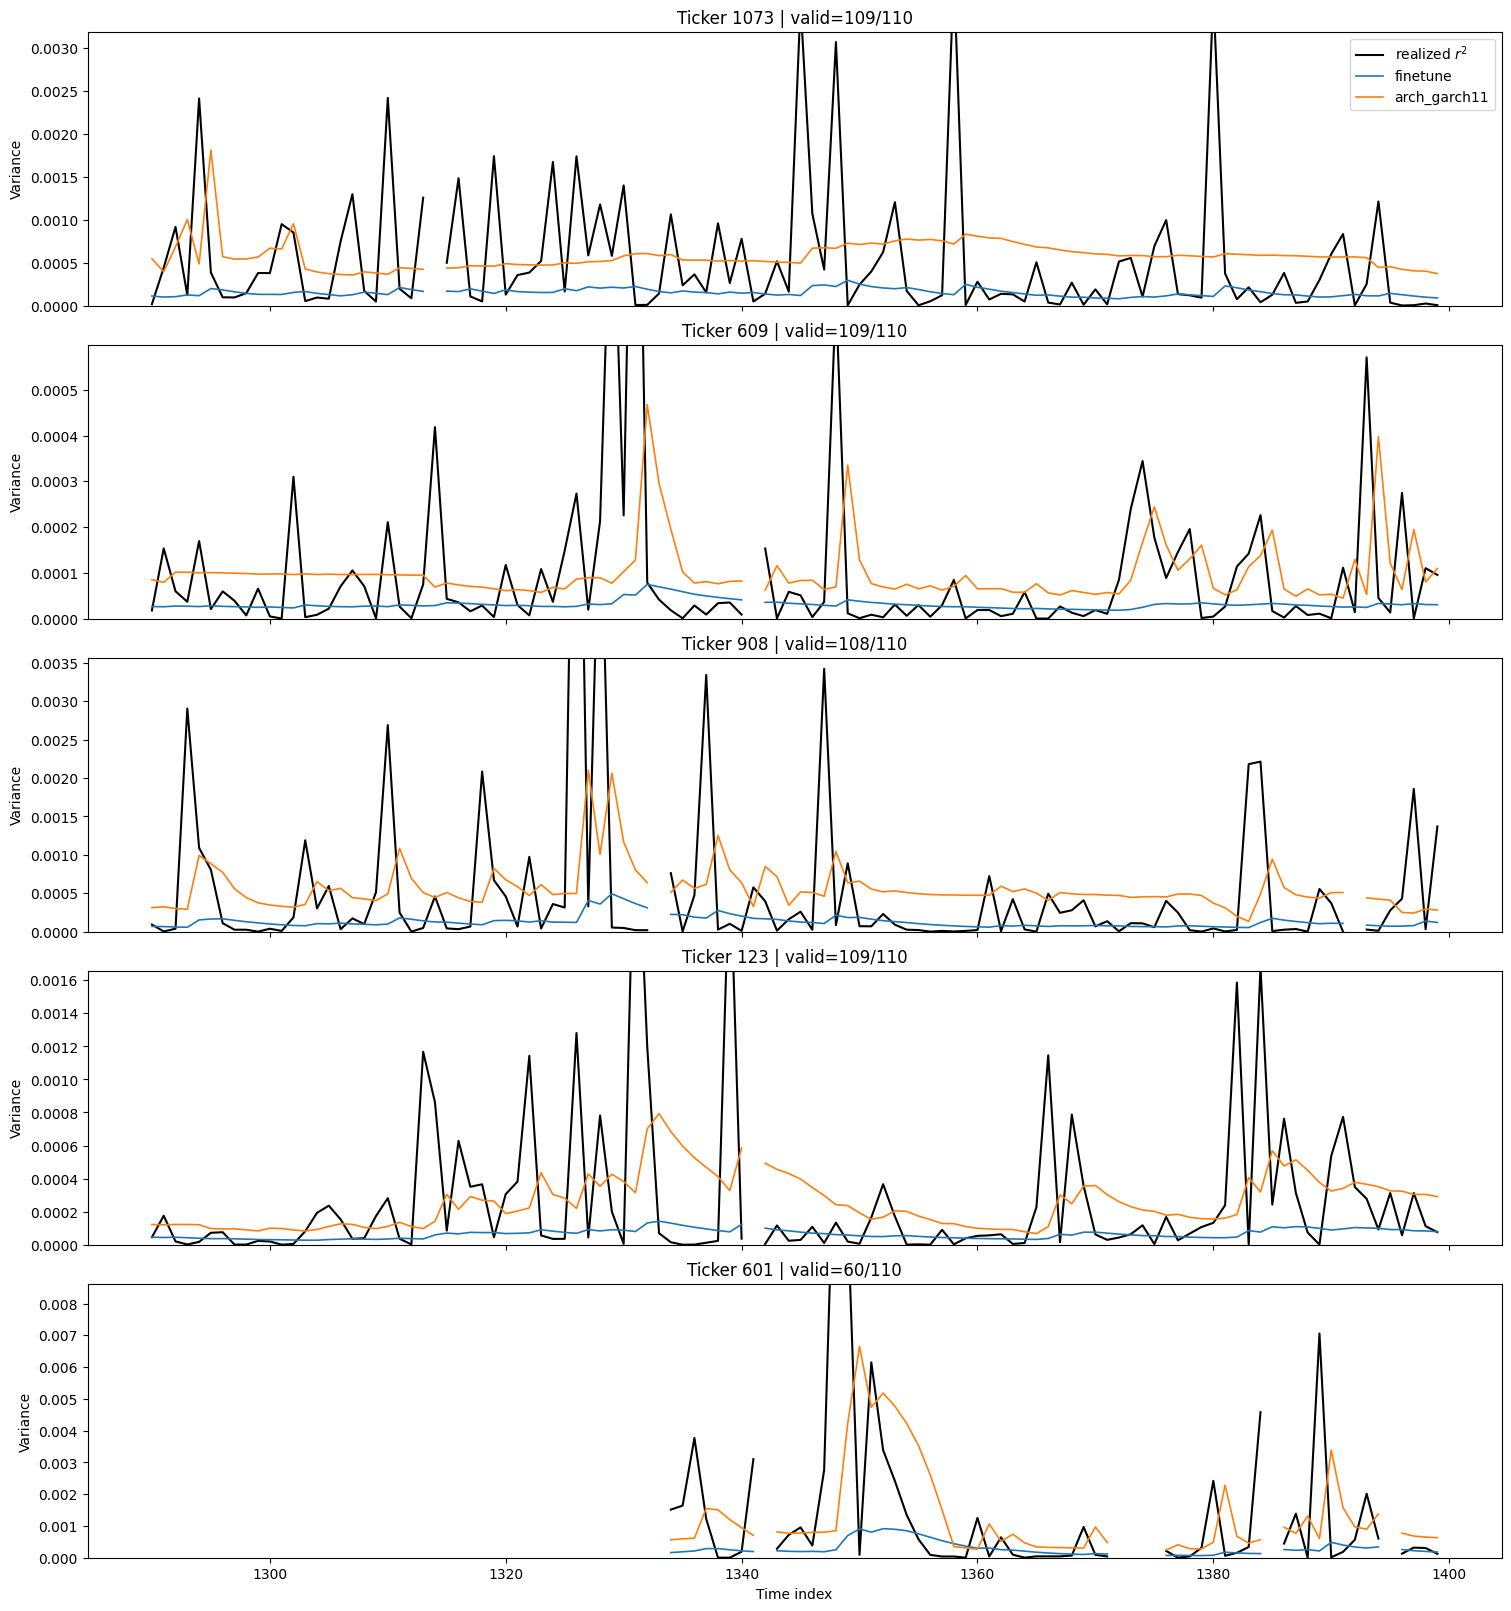

In [21]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from arch import arch_model

from model import HybridGarch

# ---------- config ----------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

R2_MIN = 1e-8
ZERO_RATIO_MAX = 0.20
EPS = 1e-12

N_SERIES = 5
T_PLOT = 120   # augmente si tu veux (ARCH devient lent)

# checkpoint finetune
FINETUNE_CKPT = "finetune_real_zeroaware_r2min1e8_best.pt"
if not Path(FINETUNE_CKPT).exists():
    FINETUNE_CKPT = "finetune_real_zeroaware_best.pt"
if not Path(FINETUNE_CKPT).exists():
    FINETUNE_CKPT = "finetune_real_fixednorm_best.pt"
if not Path(FINETUNE_CKPT).exists():
    FINETUNE_CKPT = "finetune_real_best.pt"

# stats train (normalisation)
train_block = returns_values[TRAIN_RANGE[0]:TRAIN_RANGE[1], :]
mean_train = float(train_block.mean())
std_train = float(train_block.std() + 1e-8)

def load_hybrid(path):
    m = HybridGarch(hidden=32).to(device)
    ckpt = torch.load(path, map_location=device)
    state = ckpt["model_state"] if isinstance(ckpt, dict) and "model_state" in ckpt else ckpt
    m.load_state_dict(state, strict=False)
    m.eval()
    print(f"Loaded: {path}")
    return m

@torch.no_grad()
def predict_finetune_series(model, windows_raw, mean_r, std_r):
    xb = ((windows_raw - mean_r) / (std_r + 1e-8)).astype(np.float32)[..., None]
    xb = torch.from_numpy(xb).to(device)
    out = model(xb)
    s2 = out[0] if isinstance(out, (tuple, list)) else out
    return np.maximum(s2.detach().cpu().numpy().reshape(-1) * (std_r ** 2), EPS)

def arch_1step(window_r):
    am = arch_model(window_r.astype(np.float64) * 100.0, mean="Zero", vol="GARCH", p=1, q=1, dist="normal")
    res = am.fit(disp="off")
    f = res.forecast(horizon=1, reindex=False)
    return max(float(f.variance.values[-1, 0] / (100.0 ** 2)), EPS)

finetune_model = load_hybrid(FINETUNE_CKPT)

# plage temporelle test
test_start, test_end = TEST_RANGE
t0 = max(test_start + WINDOW_SIZE, test_end - T_PLOT)
times = np.arange(t0, test_end)

# choisir 5 tickers
n_tickers = returns_values.shape[1]
rng = np.random.default_rng(SEED)
tickers = rng.choice(n_tickers, size=min(N_SERIES, n_tickers), replace=False)

fig, axes = plt.subplots(len(tickers), 1, figsize=(15, 3.2 * len(tickers)), sharex=True, constrained_layout=True)
if len(tickers) == 1:
    axes = [axes]

for ax, j in zip(axes, tickers):
    windows = []
    y_true = []
    valid = []

    for t in times:
        w = returns_values[t - WINDOW_SIZE:t, j].astype(np.float32)
        r_next = np.float32(returns_values[t, j])
        r2 = float(r_next * r_next)

        ok = (r2 >= R2_MIN) and ((w == 0.0).mean() < ZERO_RATIO_MAX)
        valid.append(ok)
        y_true.append(r2 if ok else np.nan)
        windows.append(w)

    windows = np.asarray(windows, dtype=np.float32)
    y_true = np.asarray(y_true, dtype=np.float64)
    valid = np.asarray(valid, dtype=bool)

    # finetune (batch)
    p_f = np.full(len(times), np.nan, dtype=np.float64)
    p_all = predict_finetune_series(finetune_model, windows, mean_train, std_train)
    p_f[valid] = p_all[valid]

    # ARCH (lent)
    p_a = np.full(len(times), np.nan, dtype=np.float64)
    for i, t in enumerate(times):
        if not valid[i]:
            continue
        try:
            p_a[i] = arch_1step(windows[i])
        except Exception:
            p_a[i] = np.nan

    ax.plot(times, y_true, label="realized $r^2$", color="black", lw=1.5)
    ax.plot(times, p_f, label="finetune", color="tab:blue", lw=1.2)
    ax.plot(times, p_a, label="arch_garch11", color="tab:orange", lw=1.2)

    # échelle normale (pas log)
    # ax.set_yscale("log")  # <- supprimer
    # ax.set_ylim(bottom=R2_MIN)  # <- supprimer

    # optionnel: limites lisibles en linéaire
    ymax = np.nanpercentile(np.r_[y_true, p_f, p_a], 99)
    ax.set_ylim(0.0, ymax * 1.1 if np.isfinite(ymax) else 1.0)

    ax.set_ylabel("Variance")
    ax.set_title(f"Ticker {j} | valid={valid.sum()}/{len(valid)}")


axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Time index")
plt.show()
